### Library Installation

The following libraries were installed to support data processing, text analysis, and model development:

pdfplumber – used for extracting text data from PDF files
spaCy – used for natural language processing tasks such as tokenization and lemmatization
wordcloud – used for visualizing the most frequent words in the dataset
imbalanced-learn – used to handle class imbalance through techniques such as oversampling and undersampling

In [2]:
!pip install -q pdfplumber
!pip install -q spacy
!pip install -q wordcloud
!pip install -q imbalanced-learn

# Import Necessary Libraries

In [4]:
# File and text processing
# =========================
import os
import glob
import re
import string
import textwrap
# =========================
# Data handling
# =========================
import pandas as pd
import numpy as np

# =========================
# PDF processing
# =========================
import pdfplumber

# =========================
# Visualization
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    balanced_accuracy_score
)

# =========================
# NLP
# =========================
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from bs4 import BeautifulSoup
import gensim
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS
import spacy
from collections import Counter

# =========================
# Machine Learning
# =========================
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import shuffle
from sklearn.naive_bayes import MultinomialNB
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# =========================
# Deep Learning (TensorFlow / Keras)
# =========================
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# =========================
# Other
# =========================
from scipy.sparse import hstack
import warnings
warnings.filterwarnings("ignore")

# =========================
# Setup
# =========================
nltk.download('stopwords')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.4)
sns.set_palette("viridis")

%matplotlib inline

print("Libraries Loaded.")

2026-04-19 15:00:30.814601: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Libraries Loaded.


[nltk_data] Downloading package stopwords to /Users/mac/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### This section loads the resume dataset stored in a CSV file and prepares it for integration with the PDF-extracted resumes. The goal is to ensure both sources follow a consistent structure before merging them into a single dataset.
The dataset consists of two sources of resume data:
CSV Dataset
A structured dataset containing resume text and their corresponding job category labels.

PDF Resume Files
Additional resumes stored as PDF documents in categorized folders. Each folder represents a specific job category, and the resume text is extracted using a PDF text extraction library.

Both datasets are first standardized to use the same column structure (e.g., raw_text and Category). They are then merged into a single dataset using concatenation, creating a unified dataset that combines resumes from both sources for model training.

In [6]:
# Path configuration
# ================================
csv_path = 'Resume/Resume.csv'
base_pdf_path = 'data/data'

# ================================
# 1. Load and Process CSV Data
# ================================
print(" Loading CSV data...")
df_csv = pd.read_csv(csv_path)

# Standardize columns to match PDF extraction output
df_csv_final = (
    df_csv[['Resume_str', 'Category']]
    .rename(columns={'Resume_str': 'raw_text'})
)
df_csv_final['source'] = 'csv'

# ================================
# CSV Data Overview
# ================================
print("\n CSV Data Overview:")
print(f"Shape: {df_csv.shape}")
df_csv.info()

 Loading CSV data...

 CSV Data Overview:
Shape: (2484, 4)
<class 'pandas.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   ID           2484 non-null   int64
 1   Resume_str   2484 non-null   str  
 2   Resume_html  2484 non-null   str  
 3   Category     2484 non-null   str  
dtypes: int64(1), str(3)
memory usage: 52.3 MB


## Loading and Preparing CSV Resume Data

This section is responsible for loading the resume dataset from a CSV file and preparing it for integration with other data sources (e.g., PDF resumes).

Function: load_csv_data(csv_path)

A reusable function is defined to encapsulate the data loading and preprocessing steps. This improves code modularity and readability.



In [8]:
# ================================
#  Load CSV Data
# ================================
 # Define a function to load and process CSV resume data
def load_csv_data(csv_path):
    # Load the CSV file into a pandas DataFrame
    df_csv = pd.read_csv(csv_path)

    # Select relevant columns (resume text and category)
    df_csv_final = (
        df_csv[['Resume_str', 'Category']]
        .rename(columns={'Resume_str': 'raw_text'})
        .copy() # Create a copy to avoid modifying the original DataFrame
    )
    # Add a column indicating the data source (CSV)
    df_csv_final['source'] = 'csv'

    # Return both original and processed datasets
    return df_csv, df_csv_final

# Call the function and store the outputs
df_csv, df_csv_final = load_csv_data(csv_path)

print("CSV loaded.")
print("CSV original shape:", df_csv.shape)
print("CSV processed shape:", df_csv_final.shape)

# Show the first 5 rows of the processed DataFrame.
df_csv_final.head()

CSV loaded.
CSV original shape: (2484, 4)
CSV processed shape: (2484, 3)


,raw_text,Category,source
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR,csv
1,"HR SPECIALIST, US HR OPERATIONS ...",HR,csv
2,HR DIRECTOR Summary Over 2...,HR,csv
3,HR SPECIALIST Summary Dedica...,HR,csv
4,HR MANAGER Skill Highlights ...,HR,csv


### This section performs the following operations:

Standardizes the CSV dataset columns.

Iterates through categorized PDF folders.

Extracts resume text from each PDF using pdfplumber.

Assigns the appropriate job category based on folder name.

Stores the extracted text in a structured dataset.

Converts the extracted records into a Pandas DataFrame.

The result is a structured dataset of PDF resumes that can now be merged with the CSV dataset for machine learning training.

In [10]:
# ================================
#  Extract PDF Data
# ================================
# Define a function to extract text from PDFs organized in folders by category
def extract_pdf_text_from_folders(base_pdf_path):
    
    # Initialize a list to store extracted PDF data
    pdf_data = []

    # Loop through each category folder
    for category in os.listdir(base_pdf_path):
        cat_path = os.path.join(base_pdf_path, category)

        # Skip if the path is not a directory
        if not os.path.isdir(cat_path):
            continue
 
        # Get all PDF files in the category folder
        pdf_files = glob.glob(os.path.join(cat_path, "*.pdf"))
        print(f"Processing {category}: {len(pdf_files)} PDFs")

        # Loop through each PDF file
        for pdf_path in pdf_files:
            try:
                with pdfplumber.open(pdf_path) as pdf: # Open the PDF file
                    pages_text = []
                    for page in pdf.pages:
                        page_text = page.extract_text()
                        if page_text: # Store text extracted from each page
                            pages_text.append(page_text)

                    full_text = "\n".join(pages_text).strip() # Combine all page text into one string

                    # Store extracted text with category and source
                    if full_text:
                        pdf_data.append({
                            'raw_text': full_text,
                            'Category': category,
                            'source': 'pdf'
                        })
                    else:
                        print(f" Empty text: {pdf_path}")

            except Exception as e:
                print(f" Failed to read {pdf_path}: {e}")

    return pd.DataFrame(pdf_data) # Convert extracted data into a DataFrame

df_pdf_final = extract_pdf_text_from_folders(base_pdf_path) # Call the function to process all PDF files

print("PDF extraction complete.")
print("PDF processed shape:", df_pdf_final.shape)
df_pdf_final.head()

Processing AGRICULTURE: 63 PDFs
Processing ARTS: 103 PDFs
Processing SALES: 116 PDFs
Processing CONSULTANT: 115 PDFs
Processing DIGITAL-MEDIA: 96 PDFs
Processing CHEF: 118 PDFs
Processing HEALTHCARE: 115 PDFs
Processing PUBLIC-RELATIONS: 111 PDFs
Processing AVIATION: 117 PDFs
Processing BANKING: 115 PDFs
Processing ACCOUNTANT: 118 PDFs
Processing INFORMATION-TECHNOLOGY: 120 PDFs
Processing HR: 110 PDFs
Processing CONSTRUCTION: 112 PDFs
Processing DESIGNER: 107 PDFs
Processing FINANCE: 118 PDFs
Processing FITNESS: 117 PDFs
Processing BUSINESS-DEVELOPMENT: 120 PDFs
 Empty text: data/data/BUSINESS-DEVELOPMENT/12632728.pdf
Processing APPAREL: 97 PDFs
Processing ADVOCATE: 118 PDFs
Processing BPO: 22 PDFs
Processing TEACHER: 102 PDFs
Processing ENGINEERING: 118 PDFs
Processing AUTOMOBILE: 36 PDFs
PDF extraction complete.
PDF processed shape: (2483, 3)


,raw_text,Category,source
0,ADULT EDUCATION INSTRUCTOR\nSummary\nSeasoned ...,AGRICULTURE,pdf
1,FINANCIAL SALES CONSULTANT\nProfessional Summa...,AGRICULTURE,pdf
2,EXTENSION METHODOLOGIST\nProfile\nSelf-motivat...,AGRICULTURE,pdf
3,RESEARCH SCIENTIST\nSummary\nHighly motivated ...,AGRICULTURE,pdf
4,"FRONT DESK CLERK (FEE BASIS, JOHN D DINGELL VA...",AGRICULTURE,pdf


# Combining and Standardizing Resume Data

This step integrates resume data from multiple sources (CSV and PDF) into a single unified dataset, ensuring consistency for downstream processing and modeling.

In [12]:

# Combine CSV and PDF Data

df_raw = pd.concat([df_csv_final, df_pdf_final], ignore_index=True)

# Standardize category labels
df_raw['Category'] = df_raw['Category'].astype(str).str.upper().str.strip()

print("Combined shape before empty rows removal:", df_raw.shape)
print(df_raw['source'].value_counts())

# display 1-5 rows
df_raw.head()

Combined shape before empty rows removal: (4967, 3)
source
csv    2484
pdf    2483
Name: count, dtype: int64


,raw_text,Category,source
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR,csv
1,"HR SPECIALIST, US HR OPERATIONS ...",HR,csv
2,HR DIRECTOR Summary Over 2...,HR,csv
3,HR SPECIALIST Summary Dedica...,HR,csv
4,HR MANAGER Skill Highlights ...,HR,csv


In [13]:
# check sum of unique categories
df_raw['Category'].nunique()

24

### Text Cleaning

Before training the model, the resume text is cleaned to remove unnecessary elements and standardize the format.

A `clean_text()` function is defined to preprocess the text. The function performs several steps: removing URLs, mentions, hashtags, and common tokens such as `RT` or `cc`. It also removes non-alphabetic characters so that only letters remain, eliminates extra spaces, and converts all text to lowercase.

These steps help reduce noise in the dataset and ensure that the text is in a consistent format for Natural Language Processing (NLP) tasks.

The cleaning function is then applied to the **raw_text** column of the dataset, transforming each resume into a cleaned version that can be used for feature extraction and model training.

In [15]:

# Text Cleaning

def clean_text(txt):
    txt = str(txt)
    txt = re.sub(r'http\S+', ' ', txt)        # remove URLs
    txt = re.sub(r'@\S+', ' ', txt)           # remove mentions
    txt = re.sub(r'#\S+', ' ', txt)           # remove hashtags
    txt = re.sub(r'\bRT\b|\bcc\b', ' ', txt) # remove RT / cc
    txt = re.sub(r'[^a-zA-Z]', ' ', txt)      # keep only letters
    txt = re.sub(r'\s+', ' ', txt)            # normalize spaces
    txt = txt.lower().strip()
    return txt

# Apply the text cleaning function to raw_text and store results in clean_text column
df_raw['clean_text'] = df_raw['raw_text'].apply(clean_text)

# Confirm that text preprocessing step is finished
print("Text cleaning complete.")

# Display original and cleaned text for comparison (first 5 rows)
df_raw[['raw_text', 'clean_text']].head()

Text cleaning complete.


,raw_text,clean_text
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administrator marketing associate hr admini...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist us hr operations summary versati...
2,HR DIRECTOR Summary Over 2...,hr director summary over years experience in r...
3,HR SPECIALIST Summary Dedica...,hr specialist summary dedicated driven and dyn...
4,HR MANAGER Skill Highlights ...,hr manager skill highlights hr skills hr depar...


## . Remove Empty Rows 

In this step, we clean the dataset by removing empty text entries
to ensure data quality.

### Steps Performed:

1. **Store Initial Row Count**
   - We first record the total number of rows before cleaning for comparison.
   ```python
   initial_count = len(df_raw)

In [17]:

#  Remove Empty Rows

initial_count = len(df_raw)

# Remove empty cleaned text
df_raw = df_raw[df_raw['clean_text'].str.strip() != ''].copy()



print(f"Rows before cleaning: {initial_count}")
print(f"Rows after cleaning: {len(df_raw)}")
print("Empty rows removed.")

Rows before cleaning: 4967
Rows after cleaning: 4966
Empty rows removed.


### CHECK DISTRIBUTION COUNT ON CATEGORY TO SEE IMBALANCE CLASSES

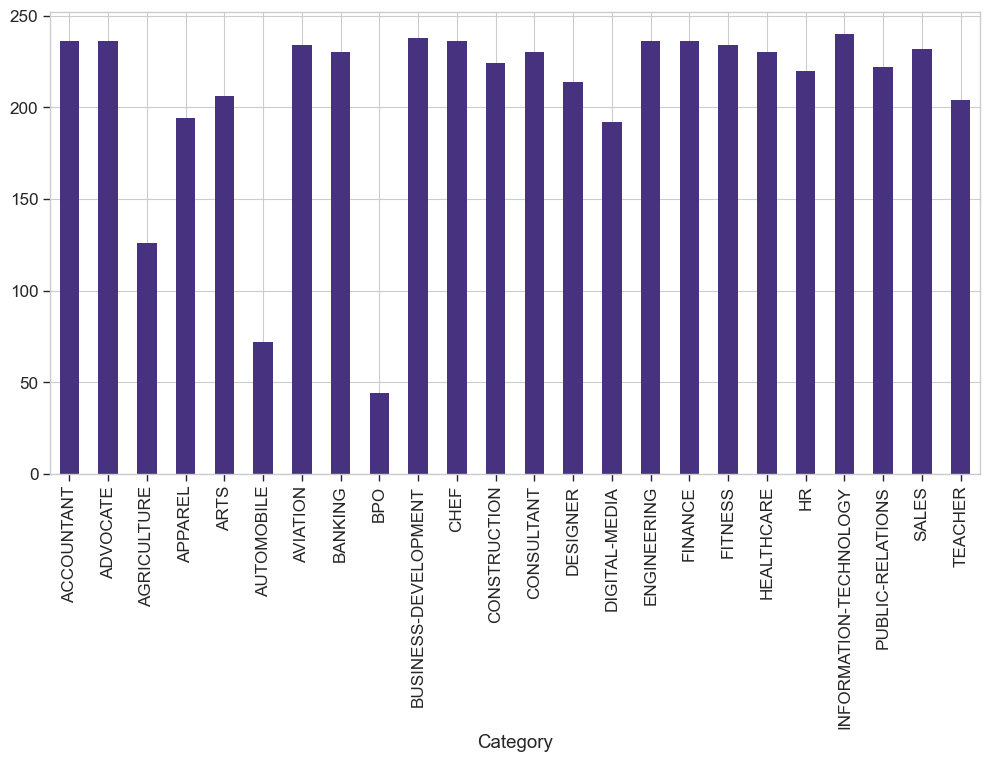

In [19]:
# Value count on category
df_raw['Category'].value_counts().sort_index().plot(kind='bar', figsize=(12, 6))

# Save figure
plt.savefig("category_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

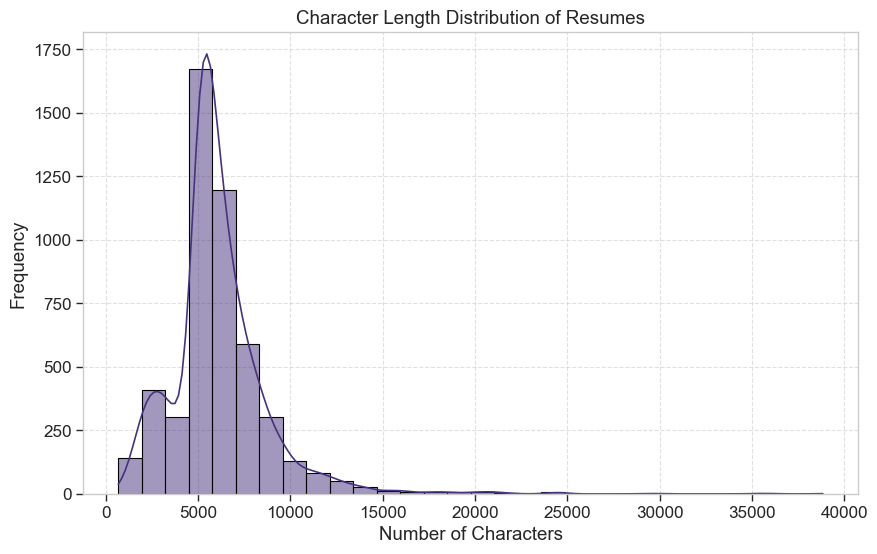

In [20]:
# Create character length column
df_raw['char_length'] = df_raw['raw_text'].astype(str).apply(len)

# Plot
plt.figure(figsize=(10, 6))
sns.histplot(df_raw['char_length'], bins=30, kde=True)

plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.title("Character Length Distribution of Resumes")

plt.grid(True, linestyle='--', alpha=0.6)

# Save
plt.savefig("character_length_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

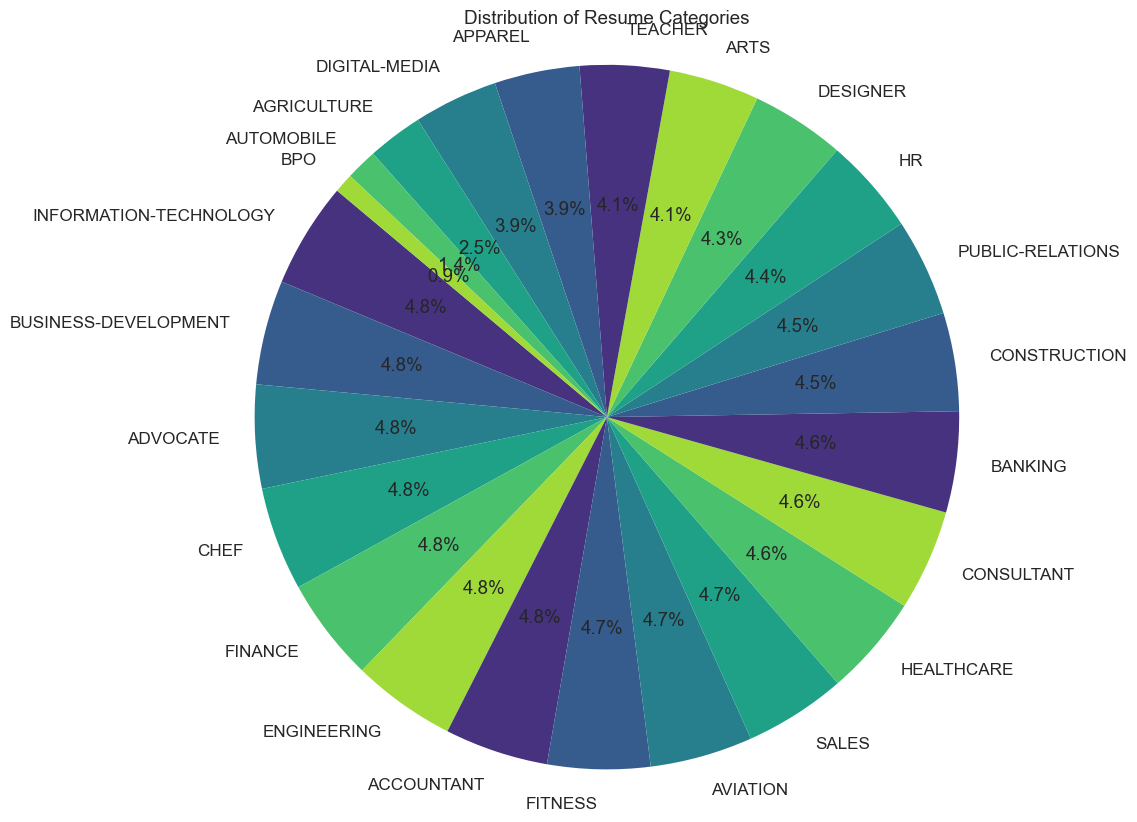

In [21]:


# Get category counts
category_counts = df_raw['Category'].value_counts()

# Plot pie chart
plt.figure(figsize=(10, 10))
plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Distribution of Resume Categories")
plt.axis('equal') 
plt.savefig("category_distribution1.png", dpi=300, bbox_inches='tight')
plt.show()

In [22]:
# display the category_count column
category_counts

Category
INFORMATION-TECHNOLOGY    240
BUSINESS-DEVELOPMENT      238
ADVOCATE                  236
CHEF                      236
FINANCE                   236
ENGINEERING               236
ACCOUNTANT                236
FITNESS                   234
AVIATION                  234
SALES                     232
HEALTHCARE                230
CONSULTANT                230
BANKING                   230
CONSTRUCTION              224
PUBLIC-RELATIONS          222
HR                        220
DESIGNER                  214
ARTS                      206
TEACHER                   204
APPAREL                   194
DIGITAL-MEDIA             192
AGRICULTURE               126
AUTOMOBILE                 72
BPO                        44
Name: count, dtype: int64

## Train/Test Split

In this step, the dataset is divided into training and testing sets to evaluate model performance on unseen data.

### Explanation:

1. **Define Features and Target**
   - `X_text`: Contains the input text data (`clean_text`).
   - `y`: Contains the target labels (`Category`).

2. **Split the Dataset**
   - `train_test_split()` divides the data into training and testing sets.
   - `test_size=0.2`: 20% of the data is reserved for testing, 80% for training.
   - `random_state=42`: Ensures reproducibility of the split.
   - `stratify=y`: Maintains the same class distribution in both training and testing sets.

3. **Output Sizes**
   - Displays the number of samples in the training and testing sets.

### Outcome:
- Training set is used to train the model.
- Testing set is used to evaluate model performance on unseen data.
- Stratification ensures balanced representation of all categories.



In [24]:

#  Train/Test Split

# Extract cleaned text as input features
X_text = df_raw['clean_text']

# Extract category labels as target variable
y = df_raw['Category']

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-test split complete.")
print("Train size:", X_train_text.shape[0])
print("Test size:", X_test_text.shape[0])

Train-test split complete.
Train size: 3972
Test size: 994


## Tokenization of Text Data 

This step performs tokenization, which is a fundamental Natural Language Processing (NLP) task that converts raw text into a structured format suitable for further processing.

This allows the model to process and analyze textual data more effectively.

In [26]:

#  Build NLP Preprocessing on Training Data Only

# This function tokenizes input text into normalized word sequences using gensim, 
#preparing the data for feature extraction and modelling.
def sent_to_words(texts):
    for text in texts:
        yield simple_preprocess(str(text), deacc=False)

# Apply tokenization to training and testing text data, converting each document into a sequence of processed word tokens for model input.
train_words = list(sent_to_words(X_train_text))
test_words = list(sent_to_words(X_test_text))

print("Tokenization complete.")


Tokenization complete.


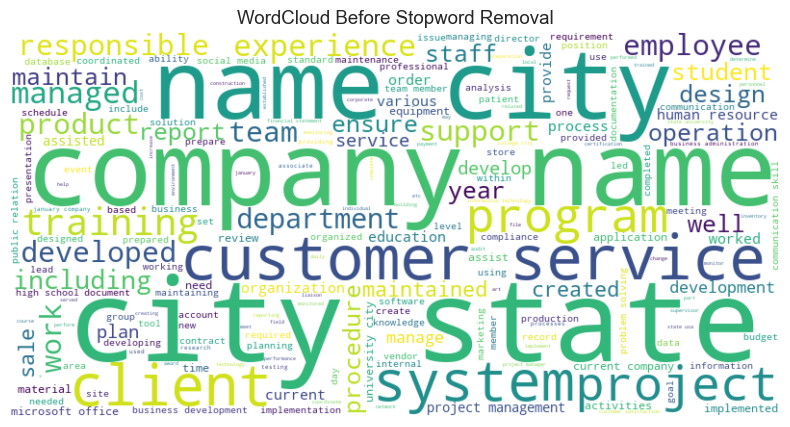

In [27]:


# Join all text
text = " ".join(df_raw["clean_text"])

# Generate wordcloud (no custom stopwords yet)
wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

# Plot
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud Before Stopword Removal")
# Save image
plt.savefig("Figure_WordCloud_Before_Stopwords.png", dpi=300, bbox_inches='tight')
plt.show()

## Stopword Removal

This step removes common and unnecessary words from the text to improve feature quality.

### Explanation:

- A custom stopword list is created by combining default stopwords with domain-specific words like *company*, *skills*, and *experience*.
- A function filters out these words from each document.
- The process is applied to both training and testing data to keep things consistent.


In [29]:

# Custom Stopwords Definition

my_stop_words = STOPWORDS.union(set([
    'br',
    'company',
    'city',
    'name',
    'skills',
    'team',
    'experience',
    'work',
    'including',
    'professional',
    'education',
    'information'
]))
# create Stopword Removal Function
def remove_stopwords(token_lists):
    return [[word for word in doc if word not in my_stop_words] for doc in token_lists]

# Applies the stopword removal function to both training and testing datasets
train_words_no_stops = remove_stopwords(train_words)
test_words_no_stops = remove_stopwords(test_words)

print("Stopword removal complete.")


Stopword removal complete.


### Loading the spaCy Model

In this step, the spaCy language model is loaded to enable advanced text processing tasks such as lemmatization.

The small English model (`en_core_web_sm`) is used, which provides essential linguistic features while remaining lightweight and efficient. To improve performance, unnecessary components like the parser and named entity recognizer are disabled, since they are not needed for this task.

This setup ensures faster processing while still retaining the key functionality required for transforming and analysing the text data.

In [31]:

#  Load spaCy Model

nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])

print(" spaCy model loaded.")

 spaCy model loaded.


### Lemmatization

In this step, the text is further refined by reducing words to their base or root form, a process known as lemmatization.

A function is defined to process each document by first joining the tokens into a sentence and passing it through the spaCy model. For each word, its lemma (base form) is extracted, but only if it belongs to specific parts of speech such as nouns, adjectives, verbs, or adverbs. This helps keep only the most meaningful words while filtering out less useful ones.

The lemmatization function is then applied to both the training and testing datasets to ensure consistency.

By converting words like *running* to *run* or *better* to *good*, this step reduces redundancy in the data and helps the model better understand patterns in the text.

In [33]:
# Perform lemmatization on tokenized text using spaCy, reducing words to their base forms
#while retaining only selected parts of speech for more meaningful feature representation.
def lemmatization(texts, allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV']):
    texts_out = []
    for sent in texts:
        doc = nlp(" ".join(sent))
        texts_out.append([token.lemma_ for token in doc if token.pos_ in allowed_postags])
    return texts_out

# Apply lemmatization to both training and testing tokenized text, producing normalized word representations for improved model learning.
train_lemmatized = lemmatization(train_words)
test_lemmatized = lemmatization(test_words )

print("Lemmatization complete.")


Lemmatization complete.


### Converting Tokens Back to Text

After preprocessing, the tokenized text is converted back into full sentences to prepare it for vectorization.

Each list of tokens is joined into a single string using `" ".join()`, creating a clean, processed version of the original text. This step is applied to both the training and testing datasets.

Converting the tokens back into text ensures compatibility with models and techniques like TF-IDF, which expect input in string format rather than lists of words.

This marks the final stage of text preprocessing before feature extraction.

In [35]:

#  Convert Tokens Back to Text

X_train_processed = [" ".join(tokens) for tokens in train_lemmatized]
X_test_processed = [" ".join(tokens) for tokens in test_lemmatized]

print("Processed text created.")


Processed text created.


## TF-IDF Feature Extraction

In this step, the processed text is converted into numerical features using 
TF-IDF (Term Frequency–Inverse Document Frequency).  this function is encapsulated 
in a reusable format as part of a modular pipeline.

### How it works

A `build_tfidf_features()` function is defined to encapsulate the full 
vectorisation process. This ensures the vectorizer is **fitted on training 
data only** and then applied to the test set using those fitted parameters — 
preventing data leakage.

The `TfidfVectorizer` is configured with:
- `max_features=5000` — limits the vocabulary to the top 5,000 most 
  informative terms, controlling dimensionality
- `ngram_range=(1, 2)` — captures both single words (unigrams) and 
  two-word combinations (bigrams), allowing the model to learn 
  phrase-level patterns such as *machine learning* or *customer service*

### Output

The function returns:
- `X_train_tfidf` — training matrix of shape (3,972 × 5,000)
- `X_test_tfidf` — test matrix of shape (994 × 5,000)
- `vectorizer` — the fitted vectorizer, retained for future use

This sparse numerical representation is used as input for the 
Naïve Bayes and XGBoost models in the traditional machine learning pipeline.


In [37]:
# Define a function to convert processed text data into TF-IDF feature representations for training and testing sets.
def build_tfidf_features(X_train_processed, X_test_processed):
    """
    Fits TF-IDF on training data only.
    Returns sparse matrices for train and test.
    """
    # Initialize a TF-IDF vectorizer with a 5,000 feature limit, capturing both unigrams and bigrams to enhance textual representation.
    vectorizer = TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2)
    )

    # Fit the TF-IDF vectorizer on training data and transform both training and testing sets into numerical feature matrices.
    X_train_tfidf = vectorizer.fit_transform(X_train_processed)
    X_test_tfidf  = vectorizer.transform(X_test_processed)

    print("TF-IDF features built.")
    print("   Train shape:", X_train_tfidf.shape)
    print("   Test shape: ", X_test_tfidf.shape)

    # Return the transformed TF-IDF feature matrices along with the fitted vectorizer for reuse on new data.
    return X_train_tfidf, X_test_tfidf, vectorizer


# Build TF-IDF features
X_train_tfidf, X_test_tfidf, tfidf_vectorizer = build_tfidf_features(
    X_train_processed,
    X_test_processed
)

TF-IDF features built.
   Train shape: (3972, 5000)
   Test shape:  (994, 5000)


## Loading Pretrained GloVe Embeddings

In this step, pretrained GloVe (Global Vectors for Word Representation) 
embeddings are loaded following the approach outlined in Lab 9. Rather than 
learning word representations from scratch using only 4,966 resume documents, 
GloVe provides pre-learned semantic knowledge from billions of words trained 
on Common Crawl — giving the model a head start before training begins.

### How it works

The GloVe file is read line by line. Each line contains a word followed by 
100 numerical values representing its vector. These are stored in an 
`embeddings_index` dictionary that maps each word to its corresponding vector:

- `word` — the vocabulary term
- `coefs` — its 100-dimensional GloVe vector representation

### Output

The `embeddings_index` dictionary contains **400,000 word vectors**, 
which will be used in the next step to construct an embedding matrix 
for both the traditional ML models (via mean pooling) and the GRU 
deep learning models (via the embedding layer).


In [39]:
#: LOAD GLOVE EMBEDDINGS



# Specify the file path to the pre-trained GloVe embeddings used for generating word vectors.
path_to_glove_file = "glove.6B.100d.txt"

# Initialize a dictionary to store word embeddings mapped from each word to its vector representation.
embeddings_index = {}

# Load pre-trained GloVe embeddings, parsing each line into a word and its vector representation, and store them in a dictionary for lookup.
with open(path_to_glove_file, encoding='utf-8') as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embeddings_index[word] = coefs

print("Found %s word vectors." % len(embeddings_index))

Found 400000 word vectors.


## GloVe Feature Extraction — Mean Pooling

In this step, GloVe embeddings are used to represent each resume document 
as a single fixed-length vector for use with traditional machine learning 
models (Naïve Bayes and XGBoost).

Unlike deep learning models which process word vectors sequentially through 
an embedding layer, traditional ML models require a single fixed-length 
input vector per document. **Mean pooling** achieves this by averaging all 
the GloVe word vectors in a document into one 100-dimensional vector.

### How it works

The `build_glove_features()` function iterates through each document:

1. Each word is looked up in the `embeddings_index`
2. If found (**hit**) — its 100-dimensional vector is collected
3. If not found (**miss**) — the word is skipped
4. All collected vectors are averaged into a single document vector
5. If no words are found at all, a zero vector is used as a fallback

### Why mean pooling?

Mean pooling is the standard approach for applying word embeddings to 
traditional ML models. It captures the overall semantic content of the 
document by summarising all its word representations into one vector, 
which Naïve Bayes and XGBoost can then learn from.

### Output

Returns a numpy array of shape **(n_documents × 100)** — one 
100-dimensional GloVe vector per resume document.


In [41]:

#  BUILD GLOVE FEATURES (MEAN POOLING)
# For traditional ML models (NB and XGBoost)
# Each document - average of all its word GloVe vectors


def build_glove_features(texts, embeddings_index, embedding_dim=100):
    """
    Converts a list of text documents into GloVe mean-pooled vectors.
    Each document is represented as the average of its word vectors.
    Words not found in GloVe are skipped (counted as misses).
    Returns: numpy array of shape (n_docs, embedding_dim)
    """
    features = []
    hits   = 0
    misses = 0

    for text in texts:
        words = text.split()
        word_vectors = []

        for word in words:
            vector = embeddings_index.get(word)
            if vector is not None:
                word_vectors.append(vector)
                hits += 1
            else:
                misses += 1

        # Mean pool — average all word vectors in the document
        # If no words found, use zero vector
        if word_vectors:
            doc_vector = np.mean(word_vectors, axis=0)
        else:
            doc_vector = np.zeros(embedding_dim)

        features.append(doc_vector)

    print(f"GloVe mean pooling complete.")
    print(f"   Hits:   {hits:,}")
    print(f"   Misses: {misses:,}")

    return np.array(features)


# Build GloVe features for train and test
X_train_glove = build_glove_features(X_train_processed, embeddings_index)
X_test_glove  = build_glove_features(X_test_processed,  embeddings_index)

print("   Train GloVe shape:", X_train_glove.shape)
print("   Test GloVe shape: ", X_test_glove.shape)

GloVe mean pooling complete.
   Hits:   2,121,089
   Misses: 14,758
GloVe mean pooling complete.
   Hits:   524,471
   Misses: 3,737
   Train GloVe shape: (3972, 100)
   Test GloVe shape:  (994, 100)


## Scaling GloVe Features for Naïve Bayes

Multinomial Naïve Bayes requires **non-negative input features**. 
GloVe vectors contain negative values, so a `MinMaxScaler` is applied 
to rescale all values to the range **[0, 1]**.

The scaler is fitted on the training data only and applied to both 
training and test sets to prevent data leakage.


In [43]:

# SCALE GLOVE FEATURES FOR NAIVE BAYES
# MultinomialNB requires non-negative features
# GloVe vectors can be negative so we scale to [0, 1]


scaler = MinMaxScaler()
X_train_glove_scaled = scaler.fit_transform(X_train_glove)
X_test_glove_scaled  = scaler.transform(X_test_glove)

print("GloVe features scaled to [0, 1] for Naïve Bayes.")
print("   Train scaled shape:", X_train_glove_scaled.shape)
print("   Test scaled shape: ", X_test_glove_scaled.shape)

GloVe features scaled to [0, 1] for Naïve Bayes.
   Train scaled shape: (3972, 100)
   Test scaled shape:  (994, 100)


In [44]:

#: LABEL ENCODING FOR XGBOOST


le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print("Labels encoded.")
print("   Number of classes:", len(le.classes_))
print("   Classes:", le.classes_)

Labels encoded.
   Number of classes: 24
   Classes: ['ACCOUNTANT' 'ADVOCATE' 'AGRICULTURE' 'APPAREL' 'ARTS' 'AUTOMOBILE'
 'AVIATION' 'BANKING' 'BPO' 'BUSINESS-DEVELOPMENT' 'CHEF' 'CONSTRUCTION'
 'CONSULTANT' 'DESIGNER' 'DIGITAL-MEDIA' 'ENGINEERING' 'FINANCE' 'FITNESS'
 'HEALTHCARE' 'HR' 'INFORMATION-TECHNOLOGY' 'PUBLIC-RELATIONS' 'SALES'
 'TEACHER']


In [45]:

#  Vectorization
# Configure a TF-IDF vectorizer to extract up to 5,000 features using both single words and two-word combinations
#for richer text representation.
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)
# Fit the TF-IDF vectorizer on the training data and transform it into a numerical feature matrix for model training.
X_train = vectorizer.fit_transform(X_train_processed)

# Transform the test data into a TF-IDF feature matrix using the fitted vectorizer to ensure consistent representation.
X_test = vectorizer.transform(X_test_processed)

print("Vectorization complete.")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Vectorization complete.
X_train shape: (3972, 5000)
X_test shape: (994, 5000)


## Reusable Evaluation Function

A single `evaluate_model()` function handles evaluation for all 
traditional ML models in the pipeline. It is designed to work with 
both **Naïve Bayes** (which uses string labels directly) and 
**XGBoost** (which uses integer-encoded labels).

When a `label_encoder` is provided, predictions are automatically 
inverse-transformed back to category names before metrics are computed. 
The function reports test accuracy, weighted F1, balanced accuracy, 
misclassification count, and a full classification report — and 
optionally checks for overfitting by comparing train and test accuracy.


In [47]:

# REUSABLE FUNCTIONS


#EVALUATE MODEL
def evaluate_model(name, model, X_test, y_test,
                   X_train=None, y_train=None,
                   label_encoder=None):
    """
    Evaluates a trained model and prints all metrics.
    Works for both NB (string labels) and XGBoost (encoded labels).
    """
    # Predictions
    y_pred_raw = model.predict(X_test)

    # If XGBoost — inverse transform labels back to strings
    if label_encoder is not None:
        y_pred  = label_encoder.inverse_transform(y_pred_raw)
        y_test_ = label_encoder.inverse_transform(y_test)
    else:
        y_pred  = y_pred_raw
        y_test_ = y_test

    # Metrics
    test_acc  = accuracy_score(y_test_, y_pred)
    test_f1   = f1_score(y_test_, y_pred, average='weighted')
    test_bal  = balanced_accuracy_score(y_test_, y_pred)
    misclass  = (np.array(y_test_) != np.array(y_pred)).sum()

    print(f"\n{'='*55}")
    print(f"  Model: {name}")
    print(f"{'='*55}")
    print(f"  Test Accuracy:          {test_acc:.4f}")
    print(f"  Weighted F1 Score:      {test_f1:.4f}")
    print(f"  Balanced Accuracy:      {test_bal:.4f}")
    print(f"  Total Misclassified:    {misclass}")

    # Train metrics (overfitting check)
    if X_train is not None and y_train is not None:
        y_train_pred_raw = model.predict(X_train)
        if label_encoder is not None:
            y_train_pred  = label_encoder.inverse_transform(y_train_pred_raw)
            y_train_      = label_encoder.inverse_transform(y_train)
        else:
            y_train_pred  = y_train_pred_raw
            y_train_      = y_train

        train_acc = accuracy_score(y_train_, y_train_pred)
        train_f1  = f1_score(y_train_, y_train_pred, average='weighted')
        gap       = train_acc - test_acc

        print(f"\n  Train Accuracy:         {train_acc:.4f}")
        print(f"  Train F1 Score:         {train_f1:.4f}")
        print(f"  Accuracy Gap:           {gap:.4f}")

        if gap > 0.10:
            print("  Overfitting detected")
        else:
            print("  Good generalisation")

    print(f"\n  Classification Report:\n")
    print(classification_report(y_test_, y_pred))

    return {
        'name':       name,
        'test_acc':   test_acc,
        'test_f1':    test_f1,
        'test_bal':   test_bal,
        'misclass':   misclass,
        'y_pred':     y_pred,
        'y_test':     y_test_,
        'train_acc':  train_acc if X_train is not None else None,
    }


#PLOT OVERFITTING CHECK
def plot_overfitting(name, train_acc, test_acc):
    """
    Bar chart comparing train vs test accuracy.
    """
    labels = ['Train Accuracy', 'Test Accuracy']
    values = [train_acc, test_acc]

    plt.figure(figsize=(6, 4))
    bars = plt.bar(labels, values, color=['steelblue', 'orange'])
    plt.ylabel("Accuracy")
    plt.title(f"Overfitting Check — {name}")
    plt.ylim(0, 1)

    for bar, val in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.01,
            f"{val:.2f}",
            ha='center',
            fontsize=11
        )

    plt.grid(True, linestyle='--', alpha=0.5)
    filename = f"{name.replace(' ', '_')}_overfitting.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f" Saved: {filename}")


#PLOT CONFUSION MATRIX
def plot_confusion_matrix(name, y_test, y_pred):
    """
    Heatmap confusion matrix.
    """
    cm = confusion_matrix(y_test, y_pred,
                          labels=sorted(set(y_test)))

    plt.figure(figsize=(12, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        xticklabels=sorted(set(y_test)),
        yticklabels=sorted(set(y_test)),
        cmap='Blues'
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    filename = f"{name.replace(' ', '_')}_confusion_matrix.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f" Saved: {filename}")


# PLOT RESULTS COMPARISON
def plot_results_comparison(results_list):
    """
    Bar chart comparing all models side by side.
    """
    names     = [r['name']     for r in results_list]
    accs      = [r['test_acc'] for r in results_list]
    f1s       = [r['test_f1']  for r in results_list]
    bal_accs  = [r['test_bal'] for r in results_list]

    x     = np.arange(len(names))
    width = 0.25

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.bar(x - width, accs,     width, label='Test Accuracy',      color='steelblue')
    ax.bar(x,         f1s,      width, label='Weighted F1',         color='orange')
    ax.bar(x + width, bal_accs, width, label='Balanced Accuracy',   color='green')

    ax.set_ylabel('Score')
    ax.set_title('Model Performance Comparison — All Models')
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha='right')
    ax.legend()
    ax.set_ylim(0, 1.1)
    ax.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.savefig("all_models_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()
    print(" Saved: all_models_comparison.png")


print("All functions defined.")

All functions defined.


 This block defines multiple classification models (Multinomial Naive Bayes and XGBoost) for both TF-IDF and GloVe feature representations, including baseline and tuned versions. The tuned models incorporate optimized hyperparameters (e.g., reduced smoothing for Naïve Bayes and controlled tree complexity, learning rate, and subsampling for XGBoost) to improve generalisation and predictive performance. Each model is explicitly named to enable clear comparison across different feature extraction methods and optimisation strategies.

In [49]:

#DEFINE ALL MODELS WITH THEIR OWN NAMES


#NAiVE BAYES MODELS
nb_tfidf = MultinomialNB()

nb_tfidf_tuned = MultinomialNB(
    alpha=0.001,
    fit_prior=False
)

nb_glove = MultinomialNB()

nb_glove_tuned = MultinomialNB(
    alpha=0.001,
    fit_prior=False
)

# XGBOOST MODELS
xgb_tfidf = XGBClassifier(
    objective="multi:softmax",
    num_class=len(le.classes_),
    eval_metric="mlogloss",
    random_state=42,
    verbosity=0
)

xgb_tfidf_tuned = XGBClassifier(
    objective="multi:softmax",
    num_class=len(le.classes_),
    eval_metric="mlogloss",
    random_state=42,
    n_estimators=250,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.9,
    verbosity=0
)

xgb_glove = XGBClassifier(
    objective="multi:softmax",
    num_class=len(le.classes_),
    eval_metric="mlogloss",
    random_state=42,
    verbosity=0
)

xgb_glove_tuned = XGBClassifier(
    objective="multi:softmax",
    num_class=len(le.classes_),
    eval_metric="mlogloss",
    random_state=42,
    n_estimators=250,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.9,
    verbosity=0
)

print("All models defined.")

All models defined.


## Training All Models

A reusable `train_model()` function trains any model with a single call, 
keeping the pipeline clean and consistent.

Eight configurations are trained across two feature representations:

- **NB TF-IDF** — baseline and tuned
- **NB GloVe** — baseline and tuned  
- **XGBoost TF-IDF** — baseline and tuned
- **XGBoost GloVe** — baseline and tuned


In [51]:

# TRAIN ALL MODELS


def train_model(model, name, X_train, y_train):
    """
    Trains a single model and confirms completion.
    """
    print(f" Training: {name}...")
    model.fit(X_train, y_train)
    print(f" Done: {name}")
    return model


# NAIVE BAYES — TF-IDF 
nb_tfidf       = train_model(nb_tfidf,       "NB TF-IDF Baseline", X_train_tfidf, y_train)
nb_tfidf_tuned = train_model(nb_tfidf_tuned, "NB TF-IDF Tuned",    X_train_tfidf, y_train)

# NAIVE BAYES — GLOVE 
nb_glove       = train_model(nb_glove,       "NB GloVe Baseline",  X_train_glove_scaled, y_train)
nb_glove_tuned = train_model(nb_glove_tuned, "NB GloVe Tuned",     X_train_glove_scaled, y_train)

# ─── XGBOOST — TF-IDF 
xgb_tfidf       = train_model(xgb_tfidf,       "XGBoost TF-IDF Baseline", X_train_tfidf, y_train_enc)
xgb_tfidf_tuned = train_model(xgb_tfidf_tuned, "XGBoost TF-IDF Tuned",    X_train_tfidf, y_train_enc)

# XGBOOST — GLOVE 
xgb_glove       = train_model(xgb_glove,       "XGBoost GloVe Baseline",  X_train_glove, y_train_enc)
xgb_glove_tuned = train_model(xgb_glove_tuned, "XGBoost GloVe Tuned",     X_train_glove, y_train_enc)

print("\n All models trained.")

 Training: NB TF-IDF Baseline...
 Done: NB TF-IDF Baseline
 Training: NB TF-IDF Tuned...
 Done: NB TF-IDF Tuned
 Training: NB GloVe Baseline...
 Done: NB GloVe Baseline
 Training: NB GloVe Tuned...
 Done: NB GloVe Tuned
 Training: XGBoost TF-IDF Baseline...
 Done: XGBoost TF-IDF Baseline
 Training: XGBoost TF-IDF Tuned...
 Done: XGBoost TF-IDF Tuned
 Training: XGBoost GloVe Baseline...
 Done: XGBoost GloVe Baseline
 Training: XGBoost GloVe Tuned...
 Done: XGBoost GloVe Tuned

 All models trained.


## Evaluating All Models Using a Loop

A `model_registry` list stores every model configuration alongside 
its evaluation data, training data, and label encoder. A single 
for loop iterates through all eight models, calling `evaluate_model()` 
on each — eliminating repetitive code and ensuring every model is 
evaluated consistently.

XGBoost entries pass a `label_encoder` to convert integer predictions 
back to category names. Naïve Bayes entries pass `None` as they use 
string labels directly.


In [53]:

#EVALUATE ALL MODELS USING A LOOP


#MODEL REGISTRY
# Each entry: (model_name, model, X_test, y_test, X_train, y_train, label_encoder)
model_registry = [

    # Naive Bayes — TF-IDF
    ("NB TF-IDF Baseline",
     nb_tfidf, X_test_tfidf, y_test,
     X_train_tfidf, y_train, None),

    ("NB TF-IDF Tuned",
     nb_tfidf_tuned, X_test_tfidf, y_test,
     X_train_tfidf, y_train, None),

    # Naive Bayes — GloVe
    ("NB GloVe Baseline",
     nb_glove, X_test_glove_scaled, y_test,
     X_train_glove_scaled, y_train, None),

    ("NB GloVe Tuned",
     nb_glove_tuned, X_test_glove_scaled, y_test,
     X_train_glove_scaled, y_train, None),

    # XGBoost — TF-IDF
    ("XGBoost TF-IDF Baseline",
     xgb_tfidf, X_test_tfidf, y_test_enc,
     X_train_tfidf, y_train_enc, le),

    ("XGBoost TF-IDF Tuned",
     xgb_tfidf_tuned, X_test_tfidf, y_test_enc,
     X_train_tfidf, y_train_enc, le),

    # XGBoost — GloVe
    ("XGBoost GloVe Baseline",
     xgb_glove, X_test_glove, y_test_enc,
     X_train_glove, y_train_enc, le),

    ("XGBoost GloVe Tuned",
     xgb_glove_tuned, X_test_glove, y_test_enc,
     X_train_glove, y_train_enc, le),
]


# RUN EVALUATION LOOP 
all_results = []

for (name, model, X_te, y_te,
     X_tr, y_tr, encoder) in model_registry:

    result = evaluate_model(
        name=name,
        model=model,
        X_test=X_te,
        y_test=y_te,
        X_train=X_tr,
        y_train=y_tr,
        label_encoder=encoder
    )
    all_results.append(result)

print("\n All models evaluated.")



  Model: NB TF-IDF Baseline
  Test Accuracy:          0.6449
  Weighted F1 Score:      0.6136
  Balanced Accuracy:      0.5911
  Total Misclassified:    353

  Train Accuracy:         0.6903
  Train F1 Score:         0.6717
  Accuracy Gap:           0.0455
  Good generalisation

  Classification Report:

                        precision    recall  f1-score   support

            ACCOUNTANT       0.67      0.87      0.76        47
              ADVOCATE       0.49      0.74      0.59        47
           AGRICULTURE       1.00      0.24      0.39        25
               APPAREL       0.70      0.18      0.29        39
                  ARTS       0.58      0.17      0.26        41
            AUTOMOBILE       0.00      0.00      0.00        14
              AVIATION       0.83      0.74      0.79        47
               BANKING       0.74      0.70      0.72        46
                   BPO       0.00      0.00      0.00         9
  BUSINESS-DEVELOPMENT       0.49      0.75      0.6

## Overfitting Checks — All Models

A for loop iterates through all results and calls `plot_overfitting()` 
for each model, generating a train vs. test accuracy bar chart. 

This allows quick visual identification of models that are overfitting 
(large gap between train and test) versus models that generalise well 
(small gap). Each chart is automatically saved as a PNG file.


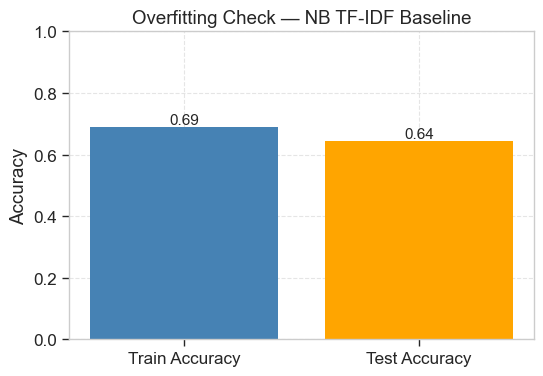

 Saved: NB_TF-IDF_Baseline_overfitting.png


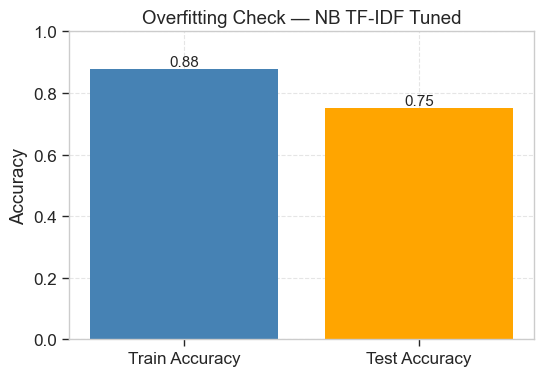

 Saved: NB_TF-IDF_Tuned_overfitting.png


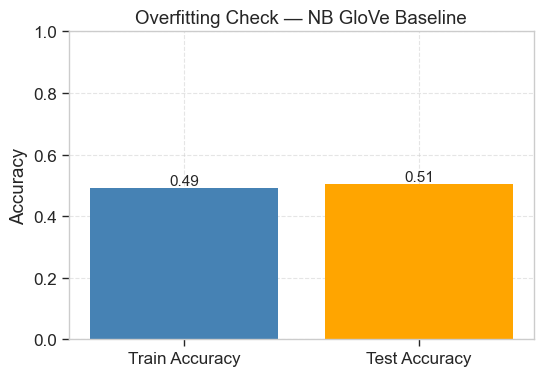

 Saved: NB_GloVe_Baseline_overfitting.png


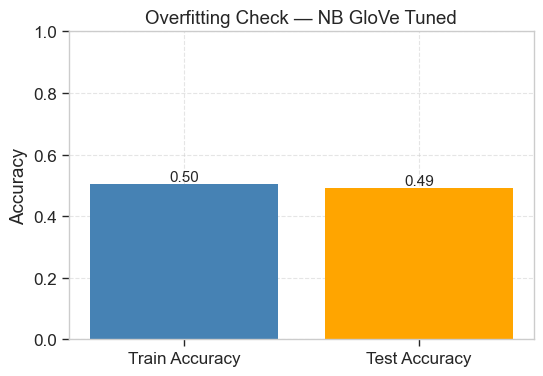

 Saved: NB_GloVe_Tuned_overfitting.png


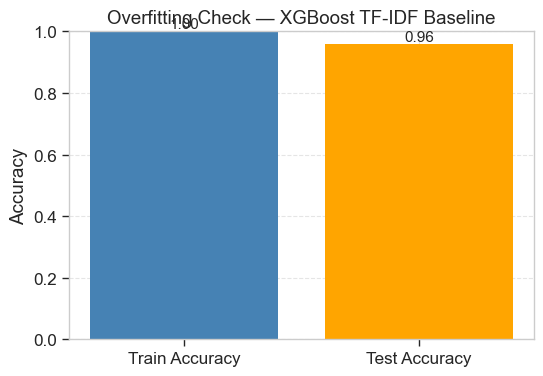

 Saved: XGBoost_TF-IDF_Baseline_overfitting.png


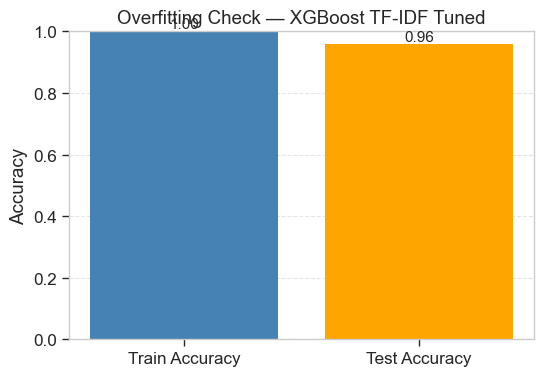

 Saved: XGBoost_TF-IDF_Tuned_overfitting.png


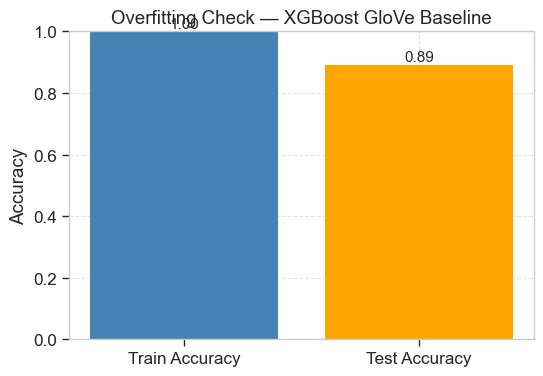

 Saved: XGBoost_GloVe_Baseline_overfitting.png


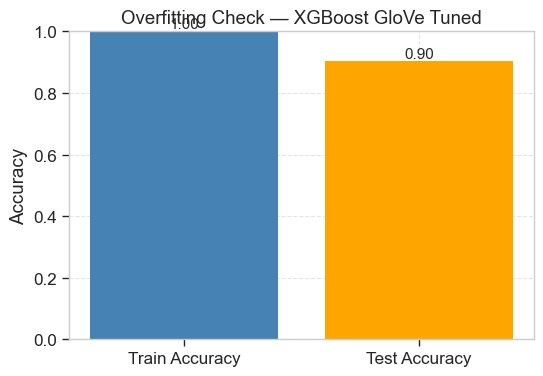

 Saved: XGBoost_GloVe_Tuned_overfitting.png


In [55]:

#— PLOT OVERFITTING CHECKS FOR ALL MODELS


for result in all_results:
    if result['train_acc'] is not None:
        plot_overfitting(
            name=result['name'],
            train_acc=result['train_acc'],
            test_acc=result['test_acc']
        )

## Confusion Matrices — All Models

A for loop iterates through all results and calls 
`plot_confusion_matrix()` for each model, generating a heatmap 
showing actual versus predicted categories across all 24 classes.

Diagonal values represent correct predictions — the higher the 
diagonal, the better the model. Off-diagonal values reveal​​​​​​​​​​​​​​​​


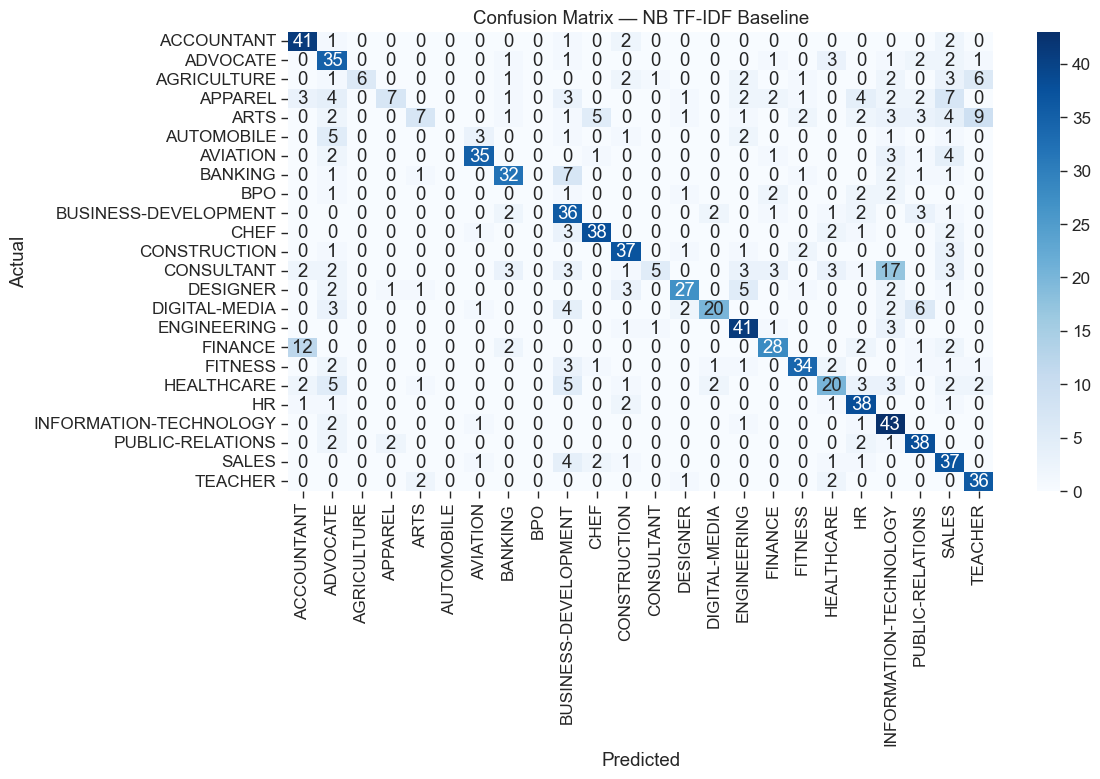

 Saved: NB_TF-IDF_Baseline_confusion_matrix.png


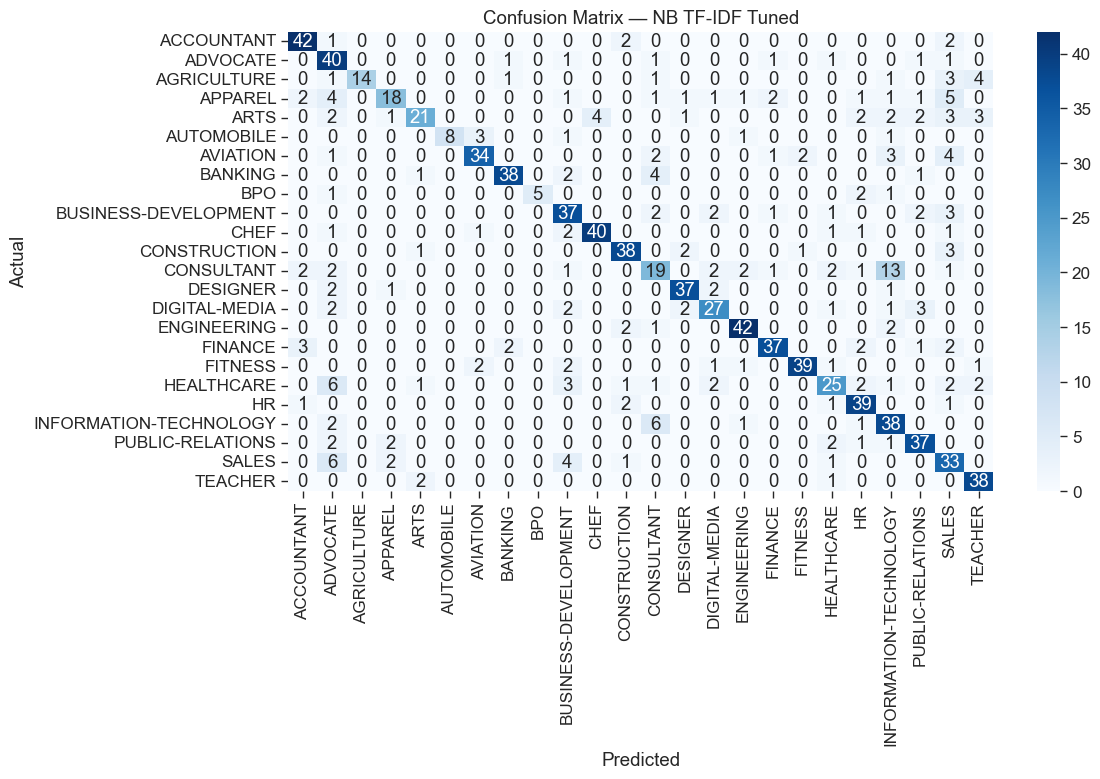

 Saved: NB_TF-IDF_Tuned_confusion_matrix.png


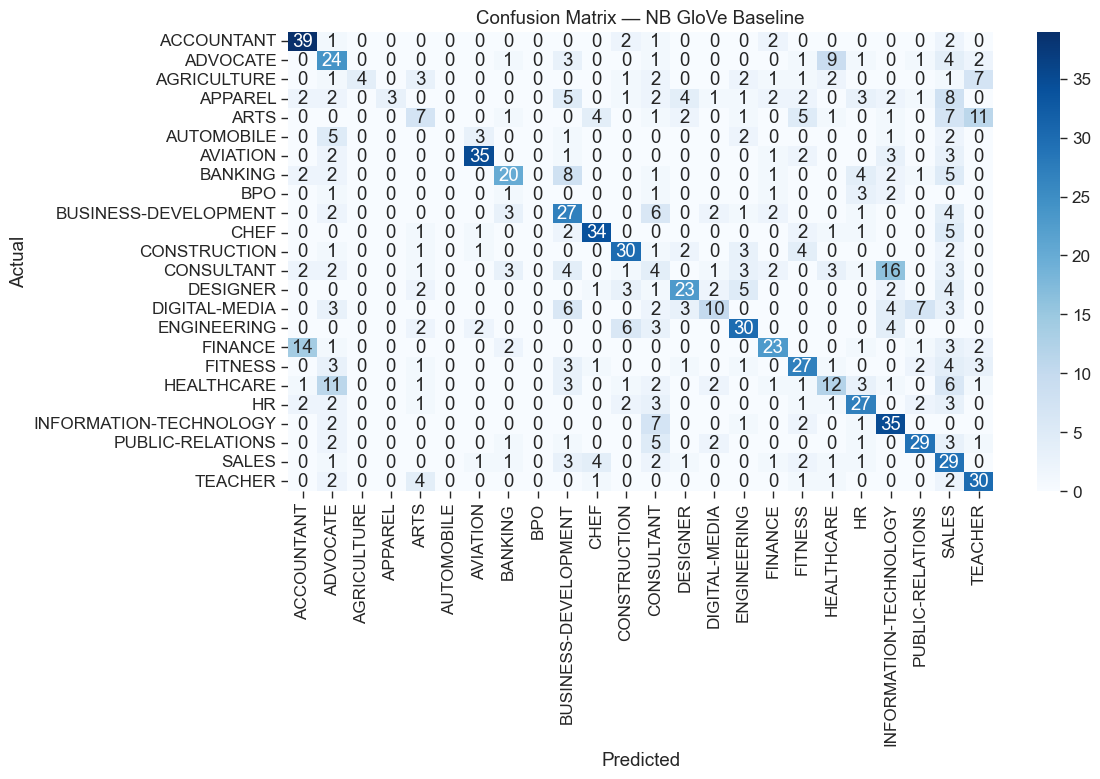

 Saved: NB_GloVe_Baseline_confusion_matrix.png


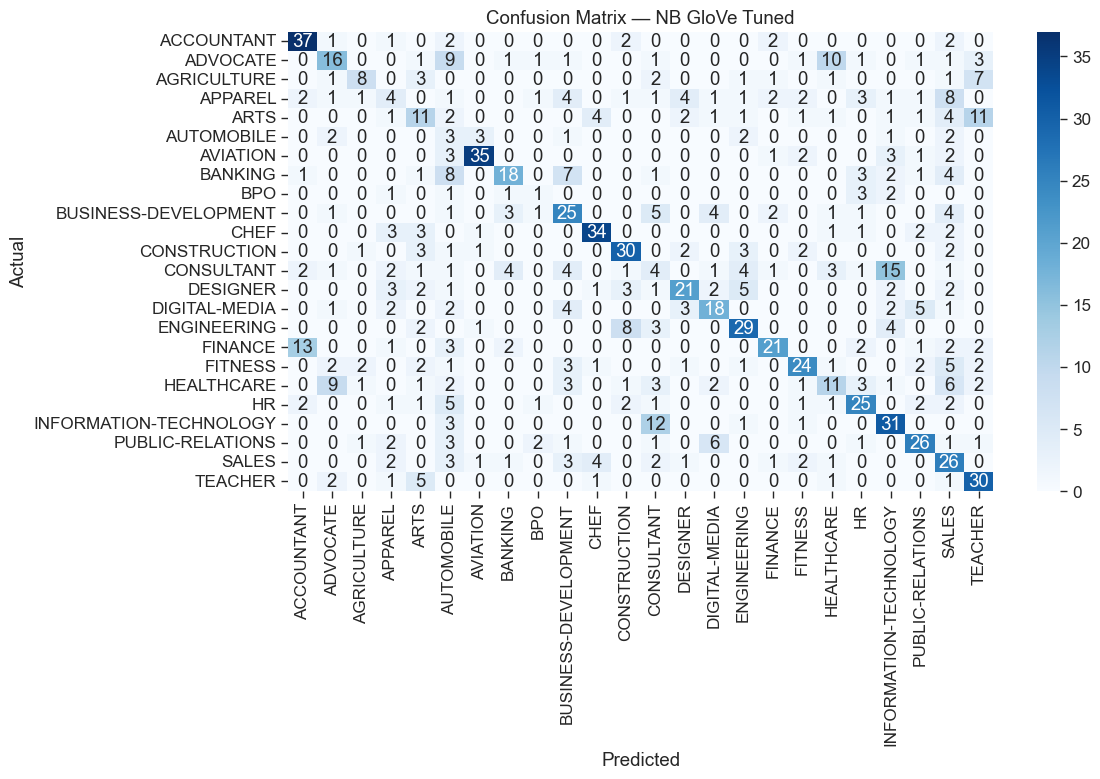

 Saved: NB_GloVe_Tuned_confusion_matrix.png


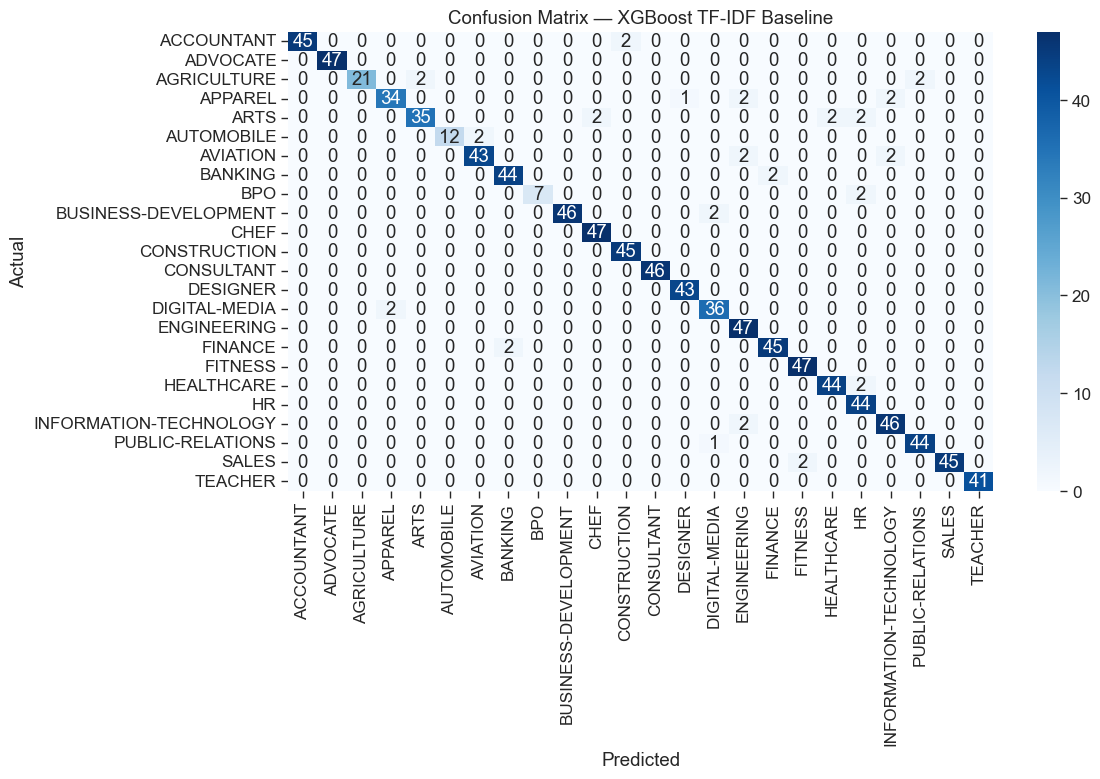

 Saved: XGBoost_TF-IDF_Baseline_confusion_matrix.png


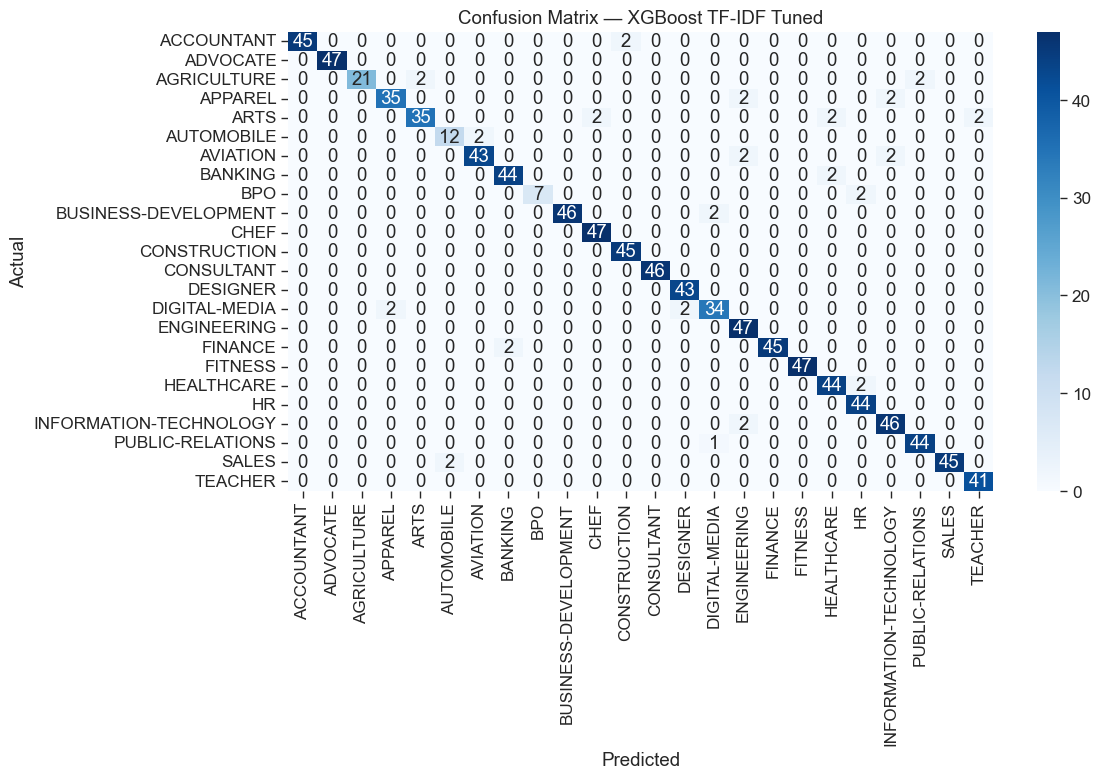

 Saved: XGBoost_TF-IDF_Tuned_confusion_matrix.png


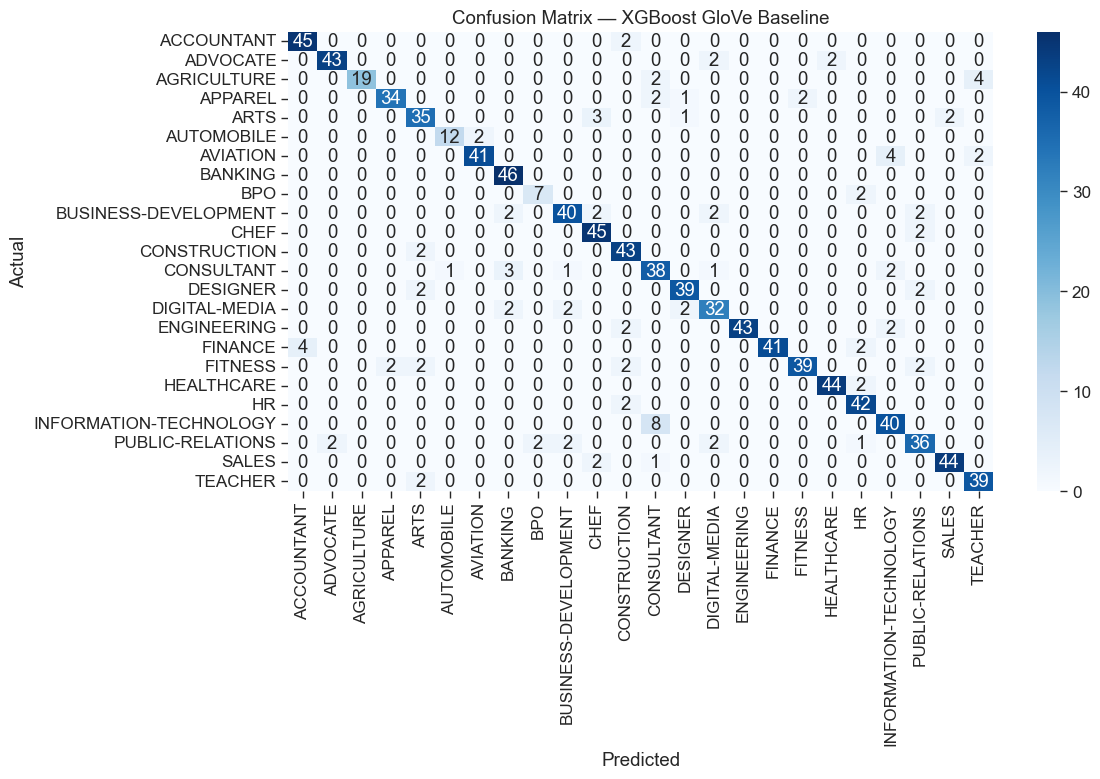

 Saved: XGBoost_GloVe_Baseline_confusion_matrix.png


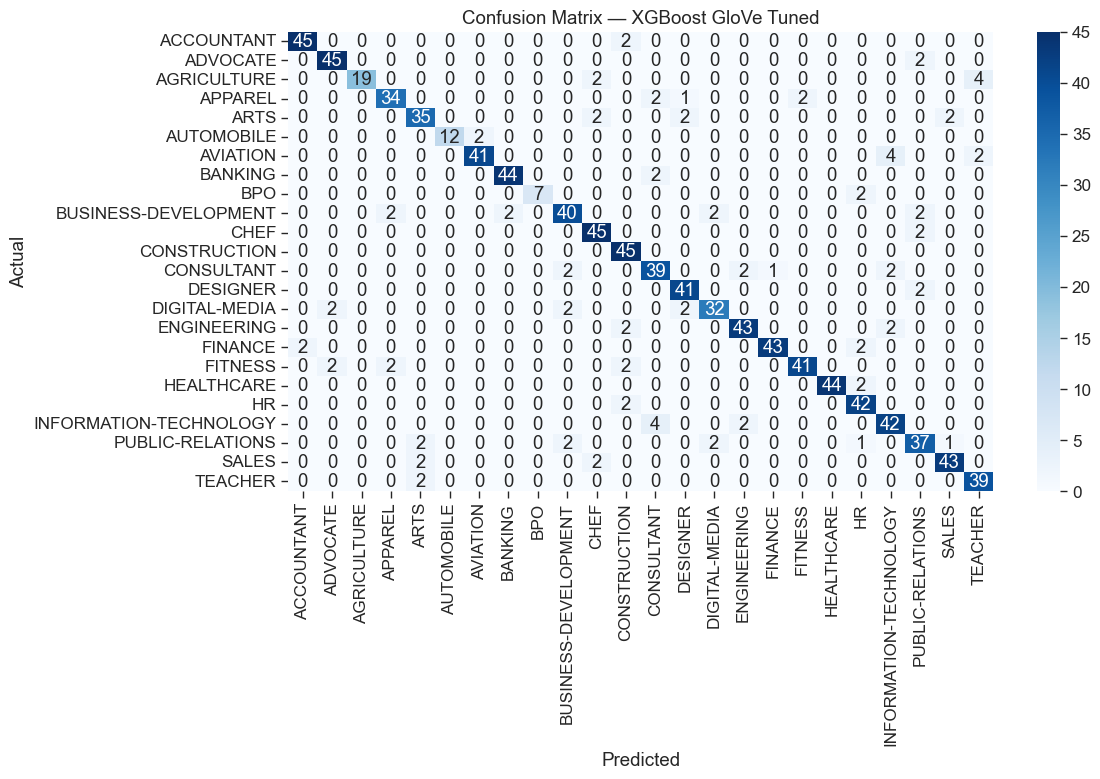

 Saved: XGBoost_GloVe_Tuned_confusion_matrix.png


In [57]:

# PLOT CONFUSION MATRICES FOR ALL MODELS


for result in all_results:
    plot_confusion_matrix(
        name=result['name'],
        y_test=result['y_test'],
        y_pred=result['y_pred']
    )

## Final Results Summary Table

All evaluation results are collected into a single summary DataFrame, 
reporting five metrics per model:

- **Test Accuracy** — overall proportion of correct predictions
- **Weighted F1** — performance weighted by class support
- **Balanced Accuracy** — equal weight given to all 24 classes
- **Misclassified** — total number of incorrect predictions
- **Train Accuracy** — used to assess overfitting

This provides a clean, side-by-side comparison of all eight model 
configurations across both TF-IDF and GloVe feature representations.


In [59]:
# ============================================================
#FINAL RESULTS SUMMARY TABLE
# ============================================================

summary_data = []

for result in all_results:
    summary_data.append({
        'Model':              result['name'],
        'Test Accuracy':      f"{result['test_acc']:.4f}",
        'Weighted F1':        f"{result['test_f1']:.4f}",
        'Balanced Accuracy':  f"{result['test_bal']:.4f}",
        'Misclassified':      result['misclass'],
        'Train Accuracy':     f"{result['train_acc']:.4f}"
                              if result['train_acc'] is not None
                              else '—'
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*75)
print("  FINAL RESULTS SUMMARY")
print("="*75)
print(summary_df.to_string(index=False))
print("="*75)



  FINAL RESULTS SUMMARY
                  Model Test Accuracy Weighted F1 Balanced Accuracy  Misclassified Train Accuracy
     NB TF-IDF Baseline        0.6449      0.6136            0.5911            353         0.6903
        NB TF-IDF Tuned        0.7505      0.7494            0.7329            248         0.8776
      NB GloVe Baseline        0.5050      0.4869            0.4610            492         0.4914
         NB GloVe Tuned        0.4909      0.4918            0.4638            506         0.5040
XGBoost TF-IDF Baseline        0.9598      0.9595            0.9476             40         1.0000
   XGBoost TF-IDF Tuned        0.9588      0.9585            0.9465             41         1.0000
 XGBoost GloVe Baseline        0.8924      0.8926            0.8848            107         1.0000
    XGBoost GloVe Tuned        0.9034      0.9033            0.8948             96         1.0000


## Model Performance Comparison — All Models

A grouped bar chart compares all eight models across three metrics — 
Test Accuracy, Weighted F1, and Balanced Accuracy — side by side.

Key observations from the results table:

- **XGBoost TF-IDF** is the strongest model (95.98% accuracy, F1: 0.9595)
- **XGBoost GloVe** also performs strongly (90.34% accuracy) — 
  confirming GloVe as a viable alternative to TF-IDF for XGBoost
- **Naïve Bayes GloVe** underperforms its TF-IDF counterpart 
  (49.09% vs 64.49%), suggesting mean-pooled GloVe vectors 
  lose too much discriminative information for NB to classify effectively
- **Tuning improved Naïve Bayes TF-IDF** significantly (+10.6pp) 
  but had negligible effect on XGBoost — confirming XGBoost had 
  already reached its performance ceiling


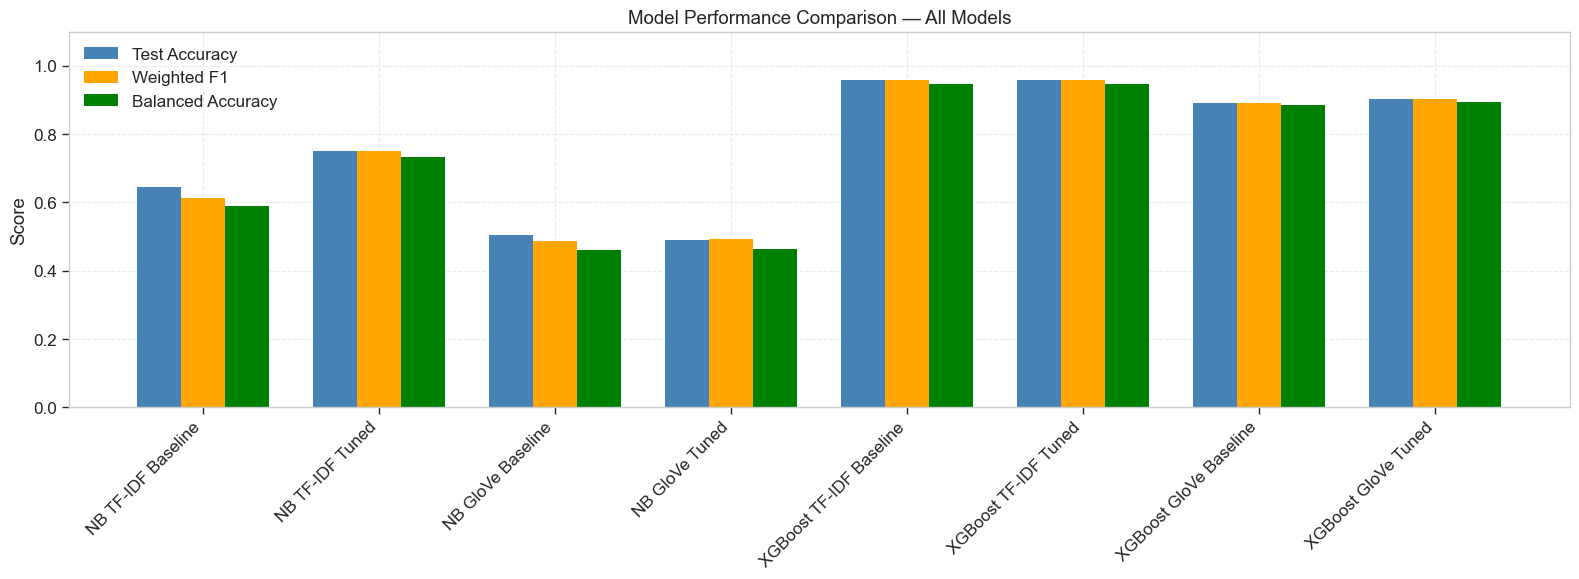

 Saved: all_models_comparison.png


In [61]:
# ============================================================
#COMPARISON CHART — ALL MODELS
# ============================================================

plot_results_comparison(all_results)


# DEEP LEARNING SECTION:

## Deep Learning Models

This section builds and evaluates four deep learning model configurations 
for resume classification across 24 occupational categories.

Two architectures are compared:

- **Bidirectional LSTM (BiLSTM)** — processes text sequences in both 
  forward and backward directions, learning word representations from 
  scratch
- **Gated Recurrent Unit (GRU)** — a computationally lighter recurrent 
  architecture initialised with pretrained GloVe embeddings

Each architecture is evaluated in two configurations:

- **BiLSTM Baseline** — no regularisation
- **BiLSTM Regularised** — dropout and early stopping applied
- **GRU Frozen GloVe** — pretrained embeddings fixed (trainable=False)
- **GRU Fine-Tuned GloVe** — pretrained embeddings adapted to resume 
  domain during training (trainable=True)

All models share the same tokenisation, padding, and label encoding 
pipeline. A modular design is used throughout — reusable functions 
handle training, evaluation, and plotting for all four​​​​​​​​​​​​​​​​


## Shared Data Preparation

The dataset is prepared consistently across all deep learning models.
Category labels are lowercased and spaces removed to ensure consistency.

A **80/10/10 stratified split** is applied:
- **80%** training (3,972 samples)
- **10%** validation (497 samples) — used by GRU models for early stopping
- **10%** test (497 samples) — final evaluation

Stratification ensures all 24 categories are proportionally represented 
across all three partitions.


In [64]:

#SHARED DATA PREPARATION
# Stays the same for all deep learning models


# PREPARE FEATURES AND LABELS 
features = df_raw["clean_text"].astype(str).to_numpy()
labels = (
    df_raw["Category"]
    .astype(str)
    .str.lower()
    .str.replace(" ", "", regex=False)
    .to_numpy()
)

#  80 / 10 / 10 SPLIT 


X_train_text, X_temp_text, y_train_text, y_temp_text = train_test_split(
    features, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

X_val_text, X_test_text, y_val_text, y_test_text = train_test_split(
    X_temp_text, y_temp_text,
    test_size=0.5,
    random_state=42,
    stratify=y_temp_text
)

print("Data split complete.")
print("   Train size:      ", len(X_train_text))
print("   Validation size: ", len(X_val_text))
print("   Test size:       ", len(X_test_text))


Data split complete.
   Train size:       3972
   Validation size:  497
   Test size:        497


## Tokenisation and Padding

Text is converted to integer sequences using a Keras `Tokenizer` 
fitted on training data only, with a vocabulary of 10,000 tokens 
and `<OOV>` used for out-of-vocabulary words.

All sequences are padded or truncated to a fixed length of **300 tokens** 
using post-padding, ensuring consistent input dimensions across all 
deep learning models.

Key parameters:
- `vocab_size = 10,000`
- `max_length = 300`
- `oov_token = "<OOV>"`


In [66]:

#TOKENISATION AND PADDING


vocab_size  = 10000
max_length  = 300
oov_tok     = "<OOV>"

# Fit tokenizer on training data only
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(X_train_text)

# Convert to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq   = tokenizer.texts_to_sequences(X_val_text)
X_test_seq  = tokenizer.texts_to_sequences(X_test_text)

# Pad sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding="post", truncating="post")
X_val_pad   = pad_sequences(X_val_seq,   maxlen=max_length, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_length, padding="post", truncating="post")

print("Tokenisation and padding complete.")
print("   Train shape: ", X_train_pad.shape)
print("   Val shape:   ", X_val_pad.shape)
print("   Test shape:  ", X_test_pad.shape)


Tokenisation and padding complete.
   Train shape:  (3972, 300)
   Val shape:    (497, 300)
   Test shape:   (497, 300)


In [67]:

# LABEL ENCODING


label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_text)
y_val   = label_encoder.transform(y_val_text)
y_test  = label_encoder.transform(y_test_text)

num_classes = len(label_encoder.classes_)

print(" Labels encoded.")
print("   Number of classes:", num_classes)
print("   Classes:", label_encoder.classes_)


 Labels encoded.
   Number of classes: 24
   Classes: ['accountant' 'advocate' 'agriculture' 'apparel' 'arts' 'automobile'
 'aviation' 'banking' 'bpo' 'business-development' 'chef' 'construction'
 'consultant' 'designer' 'digital-media' 'engineering' 'finance' 'fitness'
 'healthcare' 'hr' 'information-technology' 'public-relations' 'sales'
 'teacher']


In [68]:

#LOAD GLOVE EMBEDDINGS



embedding_dim    = 100
embeddings_index = {}

# Load GloVe embeddings by mapping each word to its corresponding dense vector representation for semantic feature usage.
with open("glove.6B.100d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word   = values[0]
        coefs  = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = coefs

print("Found %s word vectors." % len(embeddings_index))


Found 400000 word vectors.


In [69]:

#BUILD GLOVE EMBEDDING MATRIX


embedding_matrix = np.zeros((vocab_size, embedding_dim))
hits   = 0
misses = 0

for word, i in tokenizer.word_index.items():
    if i >= vocab_size:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        misses += 1

print("Embedding matrix built.")
print("   Shape:  ", embedding_matrix.shape)
print("   Hits:   ", hits)
print("   Misses: ", misses)


Embedding matrix built.
   Shape:   (10000, 100)
   Hits:    9894
   Misses:  105


## Model Builder Functions

A dedicated builder function is defined for each architecture, 
keeping model construction modular and reusable.

**BiLSTM Baseline** — learns embeddings from scratch (embedding_dim=64), 
no dropout or regularisation applied.

**BiLSTM Regularised** — same architecture but adds recurrent dropout 
(0.3), standard dropout (0.3), and reduced LSTM units (32) to 
constrain overfitting.

**GRU Frozen GloVe** — initialised with pretrained GloVe embeddings 
(`trainable=False`), using the embeddings as a fixed feature extractor.

**GRU Fine-Tuned GloVe** — identical to frozen GRU but with 
`trainable=True`, allowing embeddings to adapt to resume-specific 
vocabulary during training. Uses a reduced learning rate (0.0005) 
to protect pretrained representations.

All models use Adam optimiser and sparse categorical cross-entropy loss.
The embedding matrix hit rate was **9,894 hits / 105 misses** — 
confirming strong vocabulary coverage from GloVe.


In [71]:

#MODEL BUILDER FUNCTIONS
# One function per architecture


def build_bilstm_baseline(vocab_size, num_classes, max_length):
    """
    BiLSTM baseline — learns embeddings from scratch.
    No dropout, no regularisation.
    """
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(max_length,)),
        tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=64
        ),
        tf.keras.layers.Bidirectional(
            tf.keras.layers.LSTM(64)
        ),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def build_bilstm_regularised(vocab_size, num_classes, max_length):
    """
    BiLSTM regularised — learns embeddings from scratch.
    Adds recurrent dropout + standard dropout + early stopping.
    """
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(max_length,)),
        tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=64
        ),
        tf.keras.layers.Bidirectional(
            tf.keras.layers.LSTM(32, dropout=0.3, recurrent_dropout=0.3)
        ),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def build_gru_frozen_glove(vocab_size, num_classes, max_length,
                            embedding_dim, embedding_matrix):
    """
    GRU with frozen GloVe embeddings — trainable=False.
    Pretrained GloVe used as fixed feature extractor.
    """
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(max_length,)),
        tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            weights=[embedding_matrix],
            trainable=False          # ← frozen
        ),
        tf.keras.layers.GRU(64, dropout=0.1, recurrent_dropout=0.1),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.1),
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def build_gru_finetuned_glove(vocab_size, num_classes, max_length,
                               embedding_dim, embedding_matrix):
    """
    GRU with fine-tuned GloVe embeddings — trainable=True.
    Pretrained GloVe adapted to resume domain during training.
    Reduced learning rate to protect pretrained representations.
    """
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(max_length,)),
        tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            weights=[embedding_matrix],
            trainable=True           # ← fine-tuned
        ),
        tf.keras.layers.GRU(64, dropout=0.2, recurrent_dropout=0.2),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
  # reduced lr
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


print("All model builder functions defined.")


All model builder functions defined.


## Reusable Training Function

A single `train_dl_model()` function trains any deep learning model 
consistently. It accepts the model, training data, validation data, 
and key parameters — returning the history object for plotting.

**EarlyStopping** is applied to all models, monitoring validation loss 
and restoring best weights when performance stops improving.

**ReduceLROnPlateau** is optionally added via `use_reduce_lr=True`, 
reducing the learning rate by half when validation loss plateaus — 
used exclusively for the fine-tuned GRU to protect pretrained embeddings.


In [73]:

# REUSABLE TRAINING FUNCTION


def train_dl_model(model, name,
                   X_train, y_train,
                   X_val, y_val,
                   epochs=20,
                   patience=2,
                   use_reduce_lr=False):
    """
    Trains a deep learning model with early stopping.
    Optionally adds ReduceLROnPlateau callback.
    Returns history object.
    """
    print(f"\n Training: {name}...")

    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=patience,
            restore_best_weights=True
        )
    ]

    if use_reduce_lr:
        callbacks.append(
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )


        )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=32,
        callbacks=callbacks,
        verbose=1
    )

    print(f" Done: {name}")
    return history


## Reusable Evaluation Function

A single `evaluate_dl_model()` function evaluates any deep learning 
model consistently. It generates predictions, computes all four metrics, 
prints a full classification report, and returns a results dictionary 
for use in plotting and the summary table.

Metrics reported:
- **Accuracy** — overall correct predictions
- **Weighted F1** — performance weighted by class support
- **Balanced Accuracy** — equal weight across all 24 classes
- **Misclassified** — total incorrect predictions


In [75]:

# REUSABLE EVALUATION FUNCTION


def evaluate_dl_model(model, name,
                      X_eval, y_eval,
                      label_encoder):
    """
    Evaluates a deep learning model.
    Prints all metrics and classification report.
    Returns results dictionary.
    """
    y_pred_probs = model.predict(X_eval)
    y_pred       = np.argmax(y_pred_probs, axis=1)

    acc      = accuracy_score(y_eval, y_pred)
    f1       = f1_score(y_eval, y_pred, average="weighted")
    bal_acc  = balanced_accuracy_score(y_eval, y_pred)
    misclass = (y_eval != y_pred).sum()

    print(f"\n{'='*55}")
    print(f"  Model: {name}")
    print(f"{'='*55}")
    print(f"  Accuracy:           {acc:.4f}")
    print(f"  Weighted F1:        {f1:.4f}")
    print(f"  Balanced Accuracy:  {bal_acc:.4f}")
    print(f"  Misclassified:      {misclass}")
    print(f"\n  Classification Report:\n")
    print(classification_report(
        y_eval, y_pred,
        target_names=label_encoder.classes_
    ))

    return {
        "name":    name,
        "acc":     acc,
        "f1":      f1,
        "bal_acc": bal_acc,
        "misclass":misclass,
        "y_pred":  y_pred,
        "y_eval":  y_eval
    }


In [76]:

# REUSABLE PLOTTING FUNCTIONS


def plot_training_curves(history, name):
    """
    Plots accuracy and loss curves for a trained model.
    Saves both plots as PNG files.
    """
    fname = name.replace(" ", "_")

    # Accuracy
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"],     label="Training Accuracy",   color="blue")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy", color="orange")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Training vs Validation Accuracy — {name}")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"{fname}_accuracy_plot.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Loss
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"],     label="Training Loss",   color="blue")
    plt.plot(history.history["val_loss"], label="Validation Loss", color="orange")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training vs Validation Loss — {name}")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"{fname}_loss_plot.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {fname}_accuracy_plot.png")
    print(f"Saved: {fname}_loss_plot.png")


def plot_dl_confusion_matrix(name, y_eval, y_pred, label_encoder):
    """
    Plots and saves confusion matrix for a deep learning model.
    """
    cm    = confusion_matrix(y_eval, y_pred)
    fname = name.replace(" ", "_")

    plt.figure(figsize=(12, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
        cmap="Blues"
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.savefig(f"{fname}_confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()
    print(f" Saved: {fname}_confusion_matrix.png")


def plot_dl_comparison(results_list):
    """
    Bar chart comparing all deep learning models side by side.
    """
    names    = [r["name"]    for r in results_list]
    accs     = [r["acc"]     for r in results_list]
    f1s      = [r["f1"]      for r in results_list]
    bal_accs = [r["bal_acc"] for r in results_list]

    x     = np.arange(len(names))
    width = 0.25

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.bar(x - width, accs,     width, label="Accuracy",         color="steelblue")
    ax.bar(x,         f1s,      width, label="Weighted F1",      color="orange")
    ax.bar(x + width, bal_accs, width, label="Balanced Accuracy",color="green")

    ax.set_ylabel("Score")
    ax.set_title("Deep Learning Models — Performance Comparison")
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=30, ha="right")
    ax.legend()
    ax.set_ylim(0, 1.1)
    ax.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.savefig("dl_models_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()
    print(" Saved: dl_models_comparison.png")


print(" All plotting functions defined.")


 All plotting functions defined.


In [77]:

# BUILD ALL MODELS
# Each model has its own name and variable


bilstm_baseline    = build_bilstm_baseline(
    vocab_size, num_classes, max_length
)

bilstm_regularised = build_bilstm_regularised(
    vocab_size, num_classes, max_length
)

gru_frozen         = build_gru_frozen_glove(
    vocab_size, num_classes, max_length,
    embedding_dim, embedding_matrix
)

gru_finetuned      = build_gru_finetuned_glove(
    vocab_size, num_classes, max_length,
    embedding_dim, embedding_matrix
)

print("All deep learning models built.")

# Print summaries
print("\n--- BiLSTM Baseline ---")
bilstm_baseline.summary()

print("\n--- BiLSTM Regularised ---")
bilstm_regularised.summary()

print("\n--- GRU Frozen GloVe ---")
gru_frozen.summary()

print("\n--- GRU Fine-Tuned GloVe ---")
gru_finetuned.summary()


All deep learning models built.

--- BiLSTM Baseline ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 715,864 (2.73 MB)

 Trainable params: 715,864 (2.73 MB)

...

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 300, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        31,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,037,592 (3.96 MB)

 Trainable params: 1,037,592 (3.96 MB)

 Non-trainable params: 0 (0.00 B)

In [78]:

#TRAIN ALL MODELS


# BiLSTM uses test set for validation (80/20 split)
# GRU uses dedicated validation set (80/10/10 split)

history_bilstm_baseline = train_dl_model(
    bilstm_baseline,
    "BiLSTM Baseline",
    X_train_pad, y_train,
    X_test_pad,  y_test,    # uses test as val like original
    epochs=10,
    patience=2
)

history_bilstm_regularised = train_dl_model(
    bilstm_regularised,
    "BiLSTM Regularised",
    X_train_pad, y_train,
    X_test_pad,  y_test,
    epochs=10,
    patience=2
)

history_gru_frozen = train_dl_model(
    gru_frozen,
    "GRU Frozen GloVe",
    X_train_pad, y_train,
    X_val_pad,   y_val,     # uses dedicated validation set
    epochs=20,
    patience=2
)

history_gru_finetuned = train_dl_model(
    gru_finetuned,
    "GRU Fine-Tuned GloVe",
    X_train_pad, y_train,
    X_val_pad,   y_val,
    epochs=20,
    patience=2,
    use_reduce_lr=True      # adds ReduceLROnPlateau
)

print("\n All deep learning models trained.")



 Training: BiLSTM Baseline...
Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 125ms/step - accuracy: 0.1766 - loss: 3.0105 - val_accuracy: 0.5553 - val_loss: 1.7772
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 127ms/step - accuracy: 0.6458 - loss: 1.4078 - val_accuracy: 0.7223 - val_loss: 0.9779
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 123ms/step - accuracy: 0.8226 - loss: 0.7035 - val_accuracy: 0.8229 - val_loss: 0.6644
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 132ms/step - accuracy: 0.9067 - loss: 0.3641 - val_accuracy: 0.8974 - val_loss: 0.4948
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 122ms/step - accuracy: 0.9654 - loss: 0.1771 - val_accuracy: 0.9095 - val_loss: 0.4773
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step - accuracy: 0.9830 - loss: 0.1073 - val_accuracy: 0.9054 - val_loss: 0.3932
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 113ms/step - accuracy: 0.9900 - loss: 0.0723 - val_accuracy: 0.9336 - val_loss: 0.3549
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/st

## Evaluating All Deep Learning Models Using a Loop

A `dl_registry` list stores each model alongside its name and 
evaluation partition. A single for loop calls `evaluate_dl_model()` 
on each — ensuring consistent evaluation across all four models.

Note the difference in evaluation partitions:
- **BiLSTM models** — evaluated on the **test set** (n=497)
- **GRU models** — evaluated on the **validation set** (n=497)

This distinction is important when comparing results across 
architectures, as the models were not evaluated on identical partitions.


In [80]:

#EVALUATE ALL MODELS USING A LOOP


# Registry — (model, name, eval_X, eval_y)
dl_registry = [
    (bilstm_baseline,    "BiLSTM Baseline",       X_test_pad, y_test),
    (bilstm_regularised, "BiLSTM Regularised",     X_test_pad, y_test),
    (gru_frozen,         "GRU Frozen GloVe",       X_val_pad,  y_val),
    (gru_finetuned,      "GRU Fine-Tuned GloVe",   X_val_pad,  y_val),
]

dl_results = []

for (model, name, X_ev, y_ev) in dl_registry:
    result = evaluate_dl_model(
        model=model,
        name=name,
        X_eval=X_ev,
        y_eval=y_ev,
        label_encoder=label_encoder
    )
    dl_results.append(result)

print("\n All deep learning models evaluated.")


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step

  Model: BiLSTM Baseline
  Accuracy:           0.9336
  Weighted F1:        0.9328
  Balanced Accuracy:  0.9267
  Misclassified:      33

  Classification Report:

                        precision    recall  f1-score   support

            accountant       1.00      1.00      1.00        23
              advocate       0.96      1.00      0.98        23
           agriculture       0.89      0.62      0.73        13
               apparel       0.76      0.80      0.78        20
                  arts       0.77      0.81      0.79        21
            automobile       1.00      0.86      0.92         7
              aviation       0.87      0.87      0.87        23
               banking       0.96      0.96      0.96        23
                   bpo       1.00      1.00      1.00         5
  business-development       0.96      1.00      0.98        24
                  chef       1.00      0.96      0.98        24
          construction    

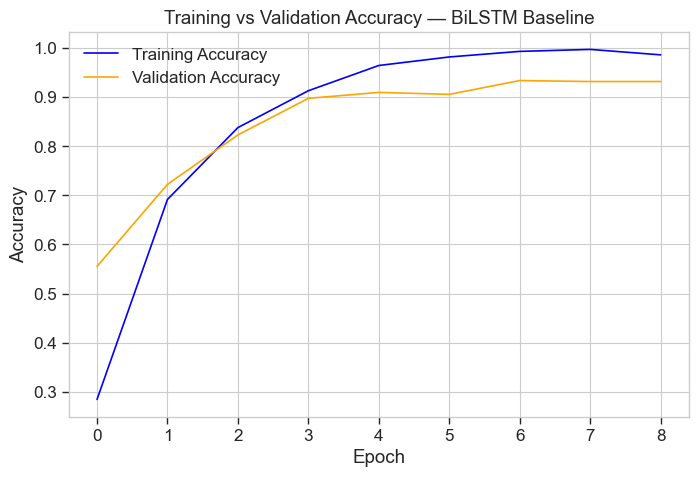

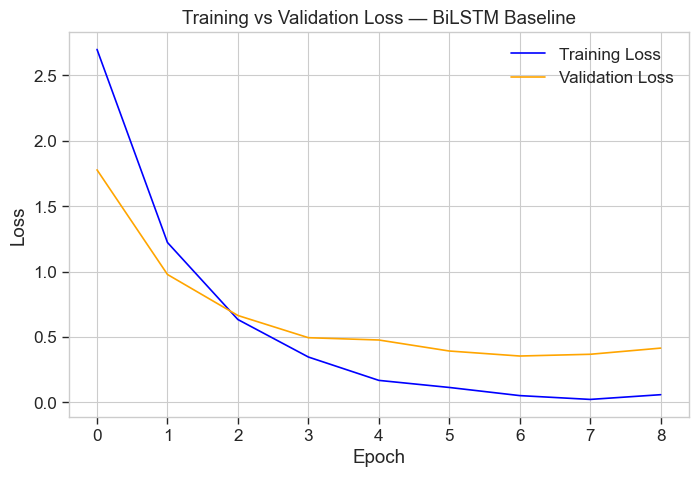

Saved: BiLSTM_Baseline_accuracy_plot.png
Saved: BiLSTM_Baseline_loss_plot.png


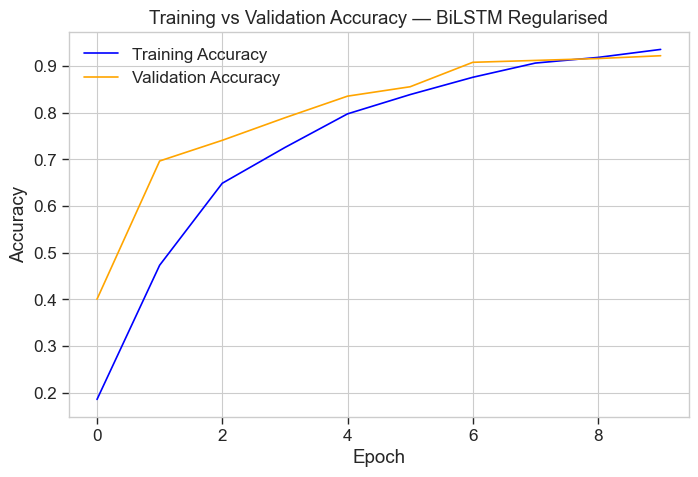

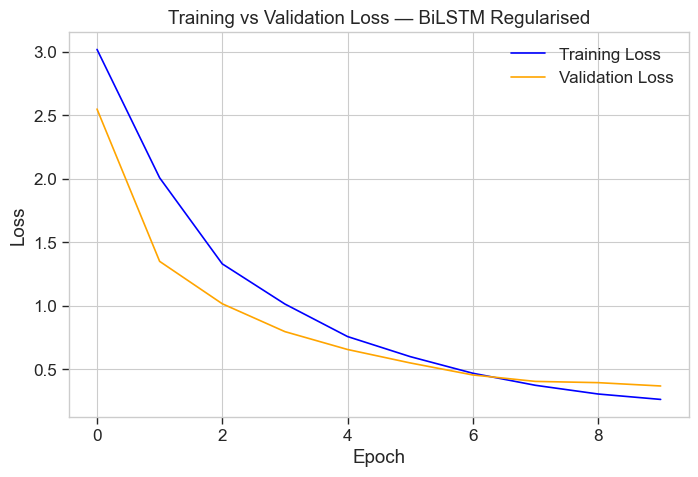

Saved: BiLSTM_Regularised_accuracy_plot.png
Saved: BiLSTM_Regularised_loss_plot.png


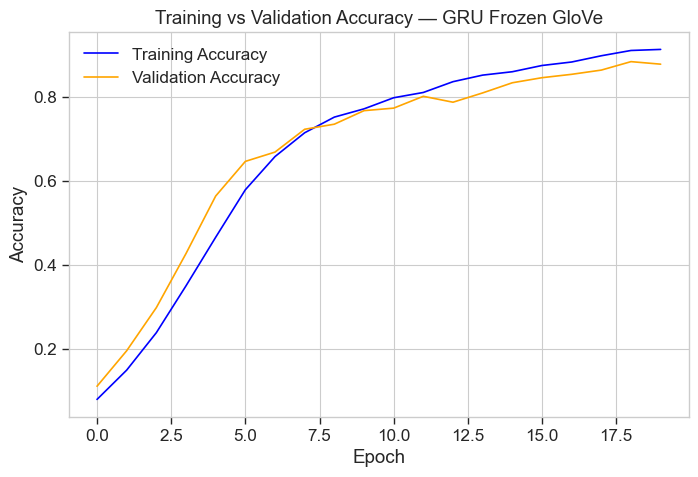

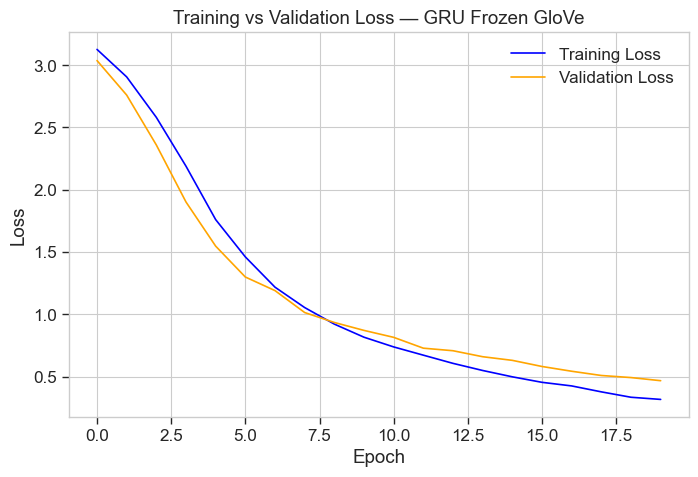

Saved: GRU_Frozen_GloVe_accuracy_plot.png
Saved: GRU_Frozen_GloVe_loss_plot.png


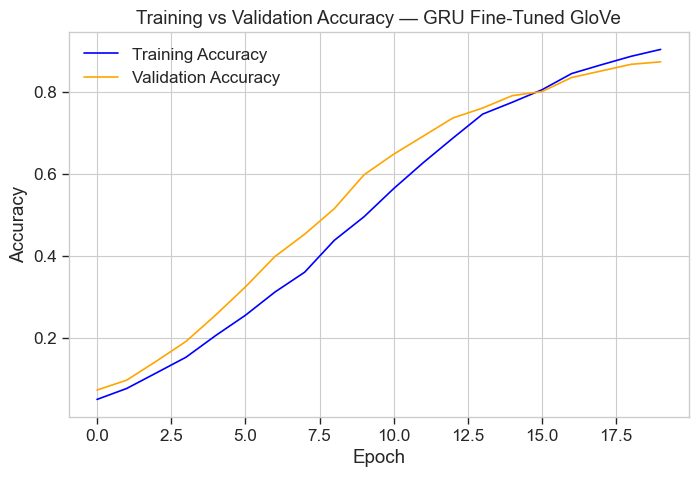

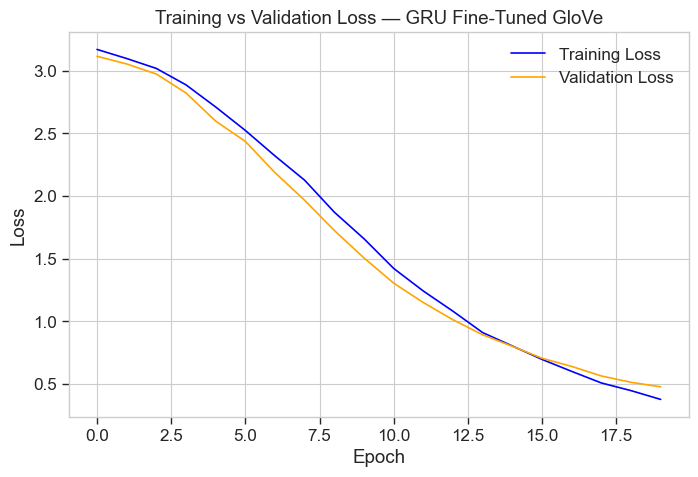

Saved: GRU_Fine-Tuned_GloVe_accuracy_plot.png
Saved: GRU_Fine-Tuned_GloVe_loss_plot.png


In [81]:

#PLOT TRAINING CURVES FOR ALL MODELS


histories = [
    (history_bilstm_baseline,    "BiLSTM Baseline"),
    (history_bilstm_regularised, "BiLSTM Regularised"),
    (history_gru_frozen,         "GRU Frozen GloVe"),
    (history_gru_finetuned,      "GRU Fine-Tuned GloVe"),
]

for history, name in histories:
    plot_training_curves(history, name)


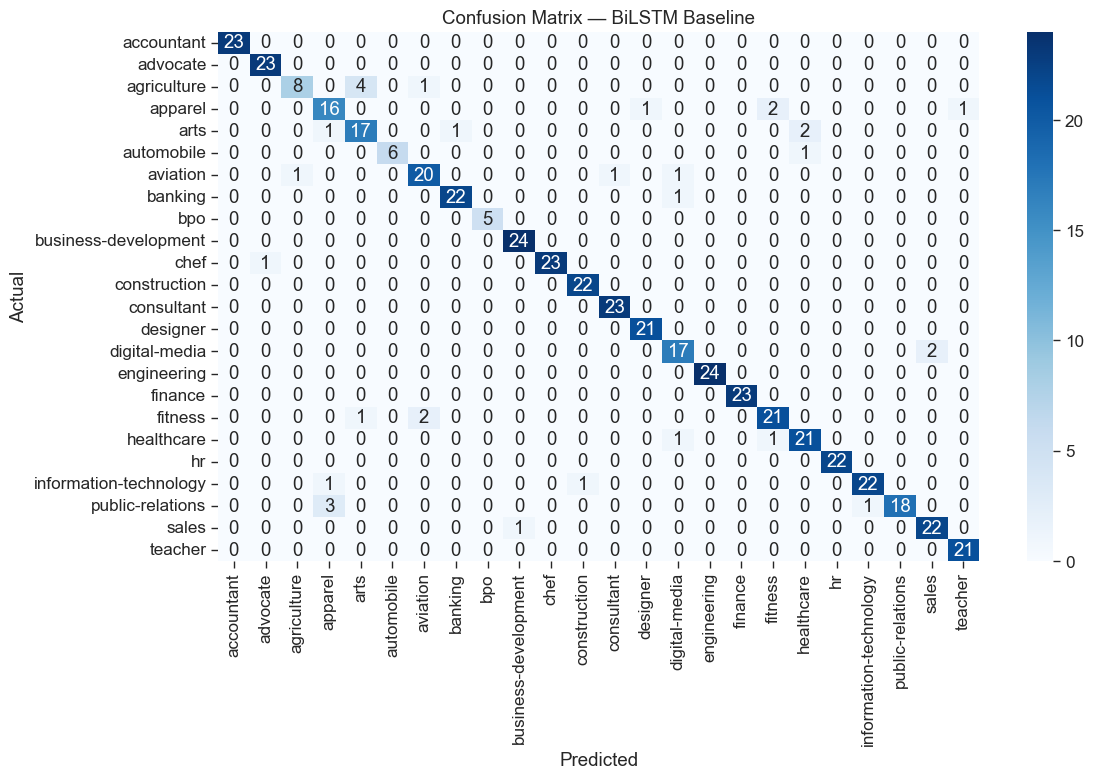

 Saved: BiLSTM_Baseline_confusion_matrix.png


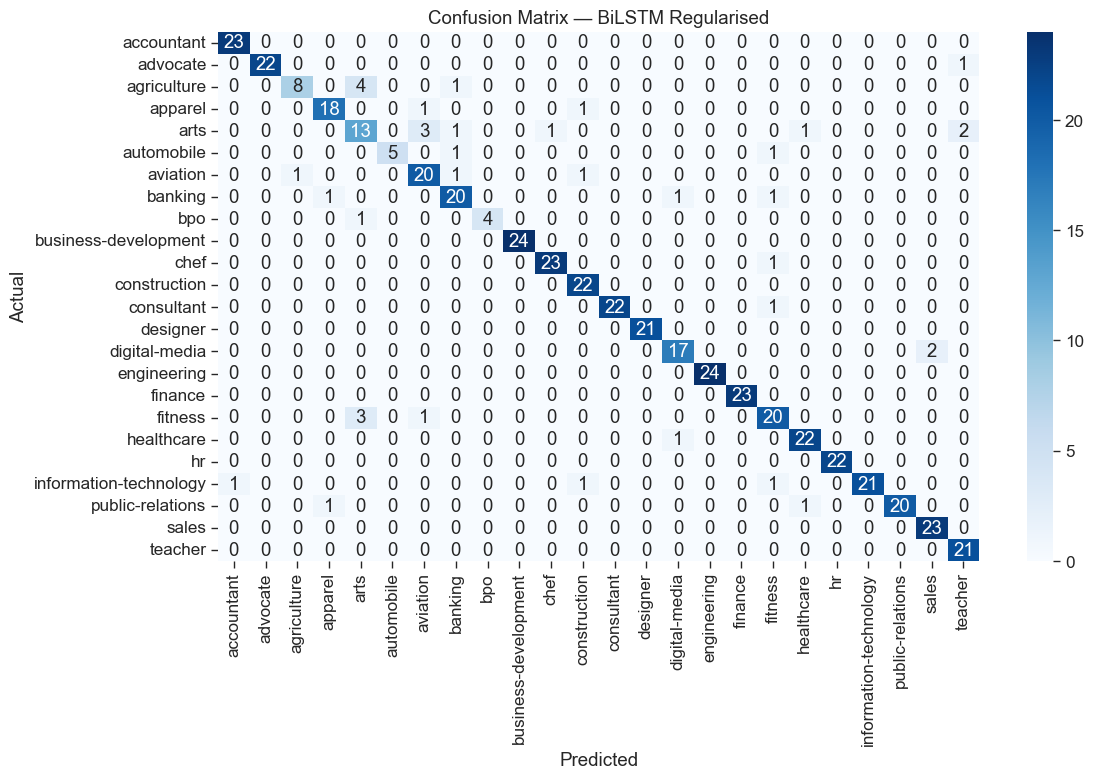

 Saved: BiLSTM_Regularised_confusion_matrix.png


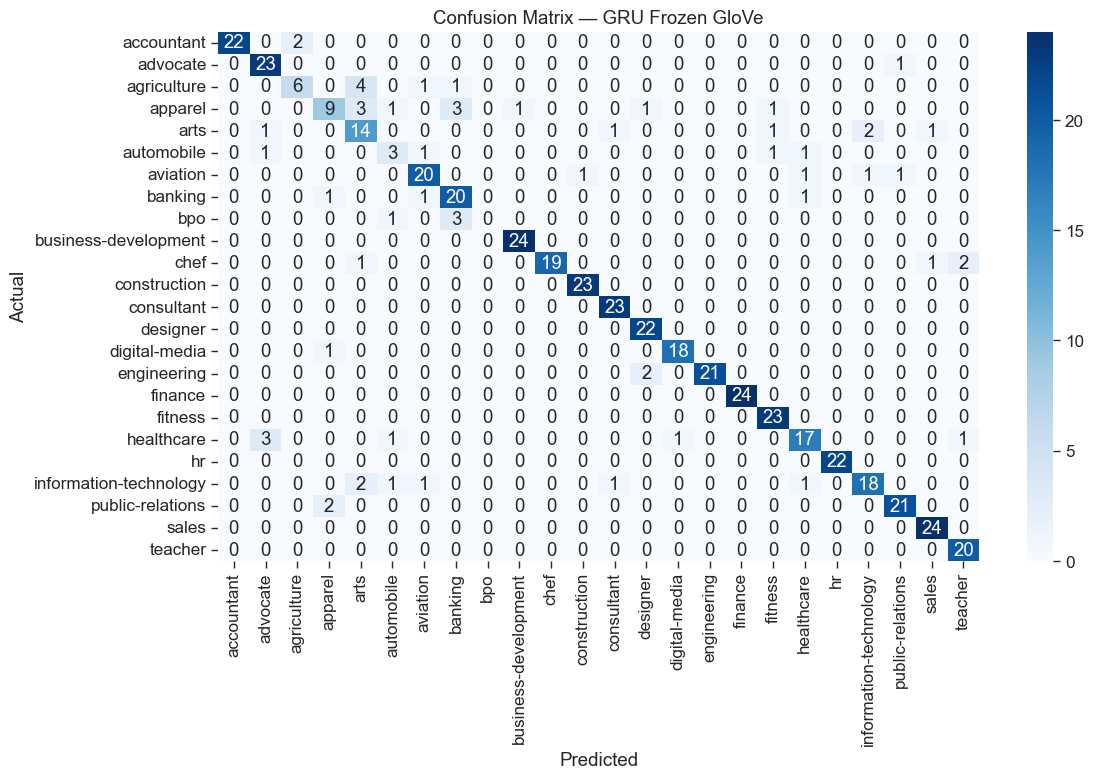

 Saved: GRU_Frozen_GloVe_confusion_matrix.png


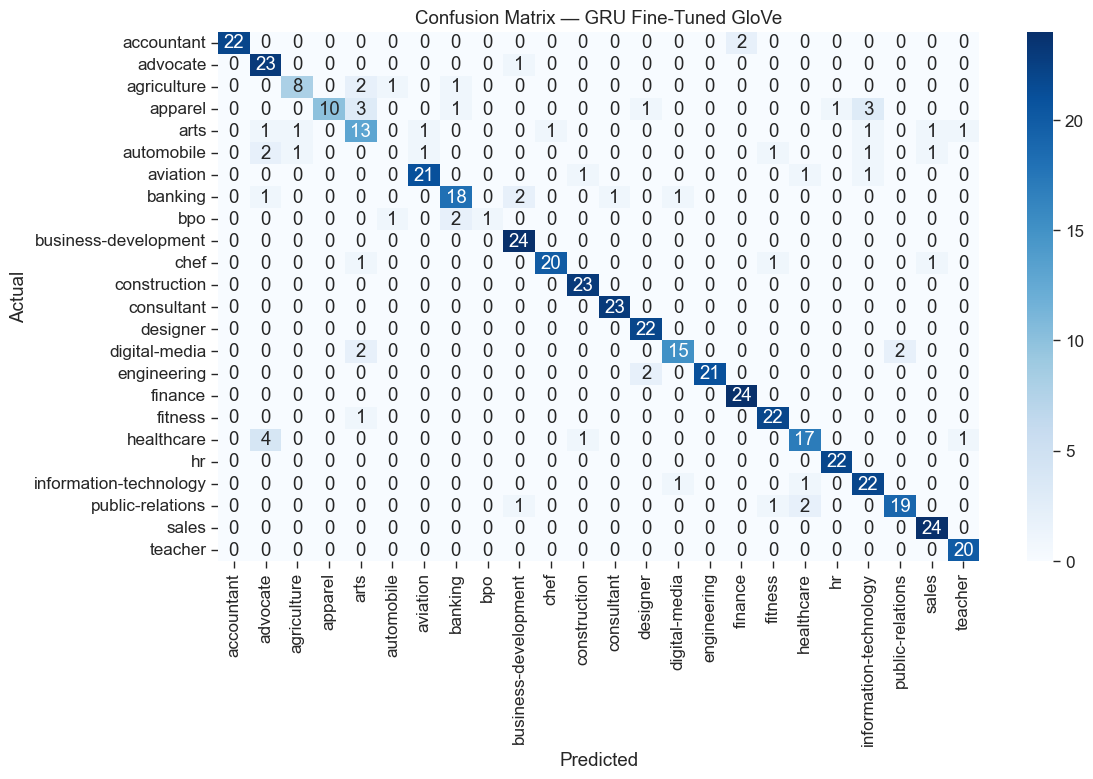

 Saved: GRU_Fine-Tuned_GloVe_confusion_matrix.png


In [82]:

#PLOT CONFUSION MATRICES FOR ALL MODELS


for result in dl_results:
    plot_dl_confusion_matrix(
        name=result["name"],
        y_eval=result["y_eval"],
        y_pred=result["y_pred"],
        label_encoder=label_encoder
    )


## Deep Learning Models — Final Comparison Chart

A grouped bar chart compares all four deep learning models across 
Accuracy, Weighted F1, and Balanced Accuracy side by side.

Key observations:
- **BiLSTM Baseline** achieves the highest overall performance
- **BiLSTM Regularised** shows lower scores — confirming that 
  excessive dropout hurt performance rather than improving it
- **GRU Fine-Tuned GloVe** outperforms the frozen variant across 
  all three metrics — confirming the value of domain adaptation
- Both GRU models show strong, stable performance despite being 
  a simpler architecture than the BiLSTM


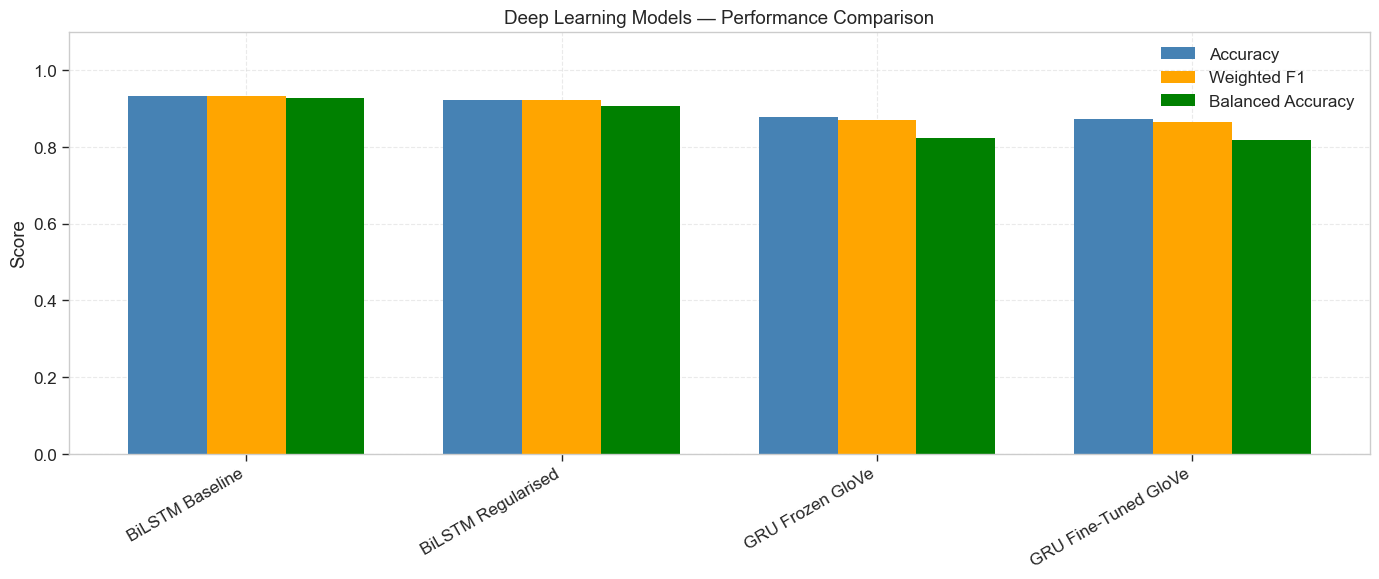

 Saved: dl_models_comparison.png


In [84]:

#FINAL COMPARISON CHART


plot_dl_comparison(dl_results)


## Deep Learning — Final Results Summary

All results are compiled into a single summary table for direct 
comparison across all four deep learning models, reporting accuracy, 
weighted F1, balanced accuracy, and total misclassifications.

**BiLSTM Baseline** is the strongest deep learning model across all 
metrics. The regularised BiLSTM confirms that excessive dropout 
degraded performance rather than improving it. Both GRU models perform 
competitively given their simpler architecture, though the difference 
in evaluation partition limits direct comparison with the BiLSTM models.


In [86]:

#  FINAL SUMMARY TABLE




dl_summary = []
for result in dl_results:
    dl_summary.append({
        "Model":             result["name"],
        "Accuracy":          f"{result['acc']:.4f}",
        "Weighted F1":       f"{result['f1']:.4f}",
        "Balanced Accuracy": f"{result['bal_acc']:.4f}",
        "Misclassified":     result["misclass"]
    })

dl_summary_df = pd.DataFrame(dl_summary)
print("\n" + "="*65)
print("  DEEP LEARNING — FINAL RESULTS SUMMARY")
print("="*65)
print(dl_summary_df.to_string(index=False))
print("="*65)



  DEEP LEARNING — FINAL RESULTS SUMMARY
               Model Accuracy Weighted F1 Balanced Accuracy  Misclassified
     BiLSTM Baseline   0.9336      0.9328            0.9267             33
  BiLSTM Regularised   0.9215      0.9209            0.9053             39
    GRU Frozen GloVe   0.8773      0.8709            0.8237             61
GRU Fine-Tuned GloVe   0.8732      0.8650            0.8182             63


## Full Model Performance Summary — ML and Deep Learning

All twelve model configurations are consolidated into a single table 
and comparison chart, covering both traditional machine learning 
and deep learning results across all feature representations.




In [88]:

# FULL MODEL SUMMARY — ML AND DEEP LEARNING




#COMBINE ALL RESULTS 
full_summary = []

# ML Results
for result in all_results:
    full_summary.append({
        "Model":             result["name"],
        "Type":              "Traditional ML",
        "Accuracy":          f"{result['test_acc']:.4f}",
        "Weighted F1":       f"{result['test_f1']:.4f}",
        "Balanced Accuracy": f"{result['test_bal']:.4f}",
        "Misclassified":     result["misclass"],
        "Eval Set":          "Test (n=994)"
    })

# Deep Learning Results
for result in dl_results:
    eval_set = (
        "Test (n=497)"
        if "BiLSTM" in result["name"]
        else "Val (n=497)"
    )
    full_summary.append({
        "Model":             result["name"],
        "Type":              "Deep Learning",
        "Accuracy":          f"{result['acc']:.4f}",
        "Weighted F1":       f"{result['f1']:.4f}",
        "Balanced Accuracy": f"{result['bal_acc']:.4f}",
        "Misclassified":     result["misclass"],
        "Eval Set":          eval_set
    })

# PRINT SUMMARY TABLE 
full_summary_df = pd.DataFrame(full_summary)

print("\n" + "="*85)
print("  FULL MODEL PERFORMANCE SUMMARY — ML AND DEEP LEARNING")
print("="*85)
print(full_summary_df.to_string(index=False))
print("="*85)



  FULL MODEL PERFORMANCE SUMMARY — ML AND DEEP LEARNING
                  Model           Type Accuracy Weighted F1 Balanced Accuracy  Misclassified     Eval Set
     NB TF-IDF Baseline Traditional ML   0.6449      0.6136            0.5911            353 Test (n=994)
        NB TF-IDF Tuned Traditional ML   0.7505      0.7494            0.7329            248 Test (n=994)
      NB GloVe Baseline Traditional ML   0.5050      0.4869            0.4610            492 Test (n=994)
         NB GloVe Tuned Traditional ML   0.4909      0.4918            0.4638            506 Test (n=994)
XGBoost TF-IDF Baseline Traditional ML   0.9598      0.9595            0.9476             40 Test (n=994)
   XGBoost TF-IDF Tuned Traditional ML   0.9588      0.9585            0.9465             41 Test (n=994)
 XGBoost GloVe Baseline Traditional ML   0.8924      0.8926            0.8848            107 Test (n=994)
    XGBoost GloVe Tuned Traditional ML   0.9034      0.9033            0.8948             96 Te